In [1]:
import pandas as pd
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/main/automobile.csv'
df = pd.read_csv(url)

In [2]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [3]:
df.columns

Index(['symboling', 'normalized-losses', 'make', 'fuel-type', 'aspiration',
       'num-of-doors', 'body-style', 'drive-wheels', 'engine-location',
       'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-type',
       'num-of-cylinders', 'engine-size', 'fuel-system', 'bore', 'stroke',
       'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
       'highway-mpg', 'price'],
      dtype='object')

# Goal & Steps:

1. Predicting Car Prices:
   - Task: Build a regression model to predict the price (y=price) of cars based on other features in the dataset. This could involve preprocessing the data, selecting relevant features, and implementing `linear regression` and `KNN` algorithm.

2. Feature Engineering:
   - Task: Challenge students to come up with creative ways to engineer new features from the existing ones. For example, they could create a new feature representing the ratio of horsepower to curb weight.

3. Exploratory Data Analysis (EDA):
   - Task: Have students perform in-depth exploratory data analysis to understand the relationships between different features. Visualization tools can be used to communicate their findings effectively.

4. Handling Missing Data:
   - Task: Teach students how to handle missing data in a dataset. They can explore different strategies such as imputation or removal of missing values.

5. Training:
   - Task: Use relavant ML Models

6. Model evaluation:
- Evaluate models and Summarizing their findings. This should include a clear explanation of the model's performance and any insights gained from the analysis.

In [4]:
df.isnull().sum()

symboling             0
normalized-losses    37
make                  0
fuel-type             0
aspiration            0
num-of-doors          2
body-style            0
drive-wheels          0
engine-location       0
wheel-base            0
length                0
width                 0
height                0
curb-weight           0
engine-type           0
num-of-cylinders      0
engine-size           0
fuel-system           0
bore                  0
stroke                0
compression-ratio     0
horsepower            0
peak-rpm              0
city-mpg              0
highway-mpg           0
price                 0
dtype: int64

In [5]:
df.shape

(202, 26)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, LabelEncoder,LabelBinarizer, StandardScaler, FunctionTransformer,  RobustScaler, MaxAbsScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score

In [7]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


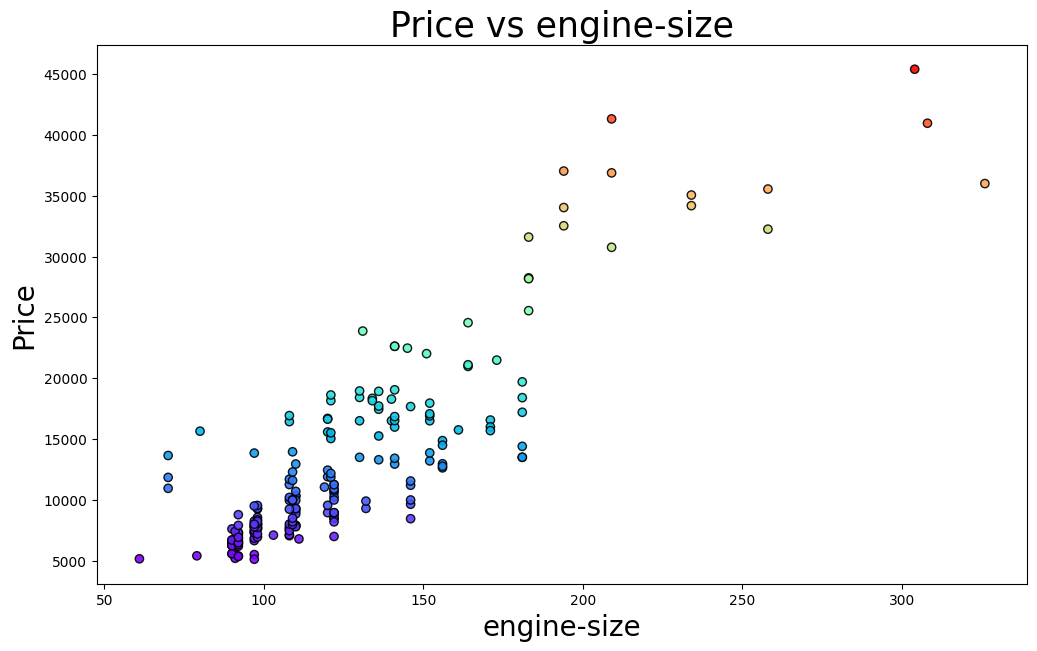

In [8]:
plt.figure(figsize=(12,7))
plt.scatter(
    df['engine-size'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)
plt.xlabel('engine-size', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.title('Price vs engine-size', fontsize=25)
plt.show()

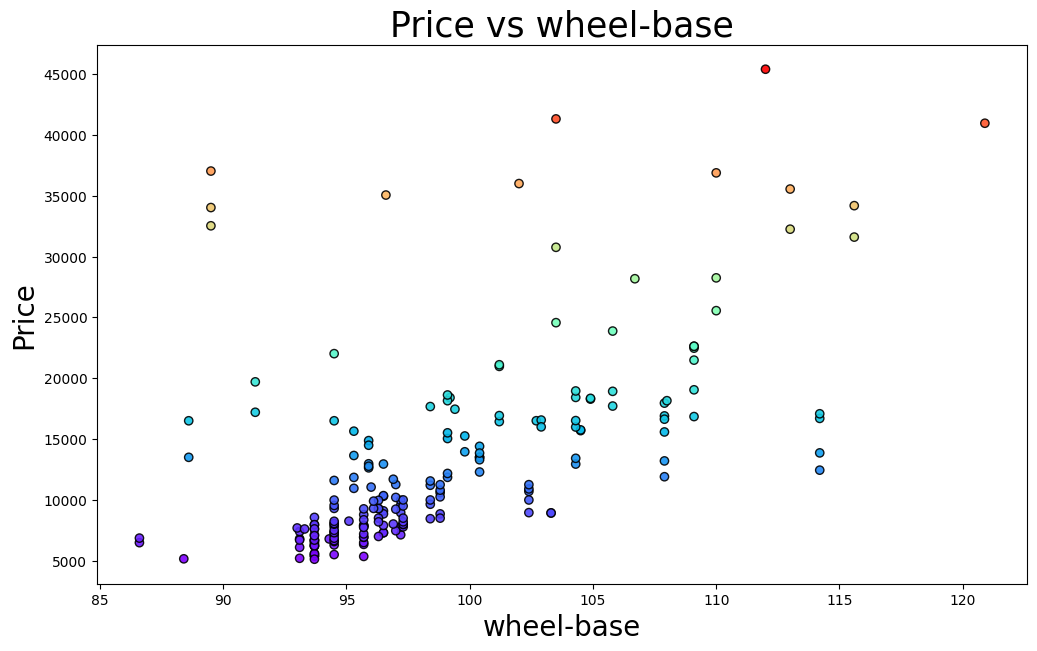

In [9]:
plt.figure(figsize=(12,7))
plt.scatter(
    df['wheel-base'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)
plt.xlabel('wheel-base', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.title('Price vs wheel-base', fontsize=25)
plt.show()

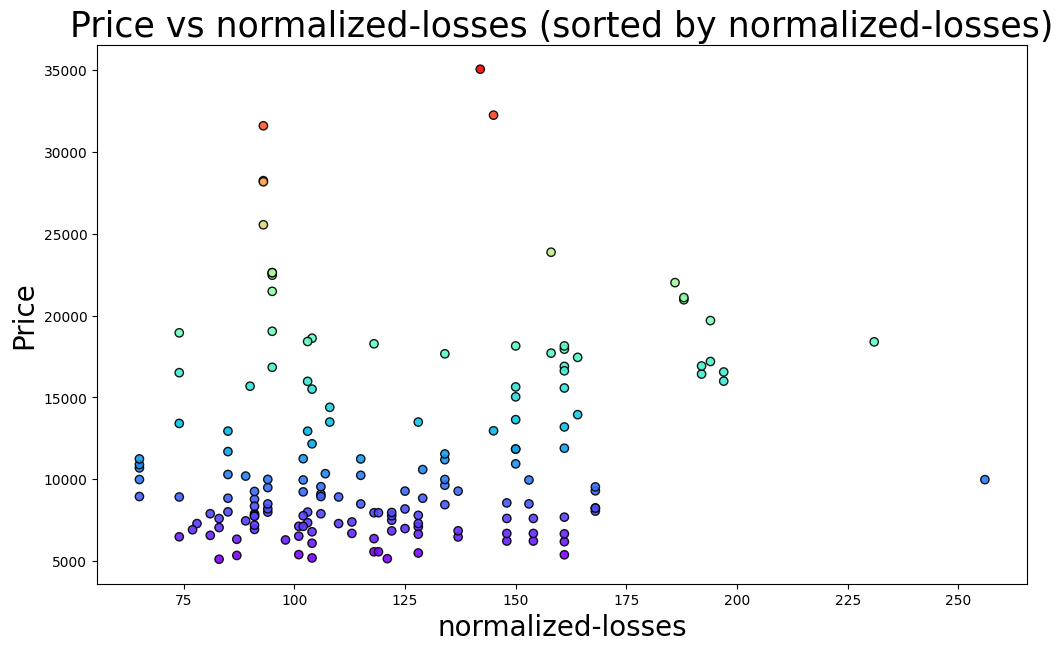

In [10]:
plt.figure(figsize=(12,7))
plt.scatter(
    df['normalized-losses'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)
    
plt.xlabel('normalized-losses', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.title('Price vs normalized-losses (sorted by normalized-losses)', fontsize=25)
plt.show()

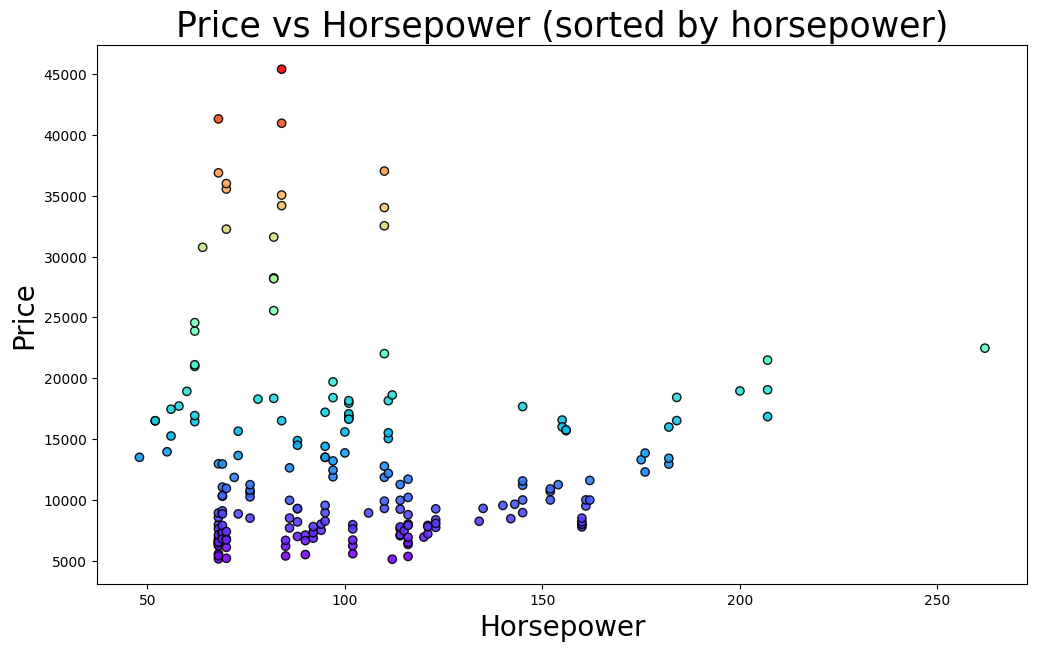

In [11]:
plt.figure(figsize=(12,7))
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')
df_sorted = df.sort_values(by='horsepower', ascending=True)
plt.scatter(
    df_sorted['horsepower'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)

plt.xlabel('Horsepower', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.title('Price vs Horsepower (sorted by horsepower)', fontsize=25)
plt.show()

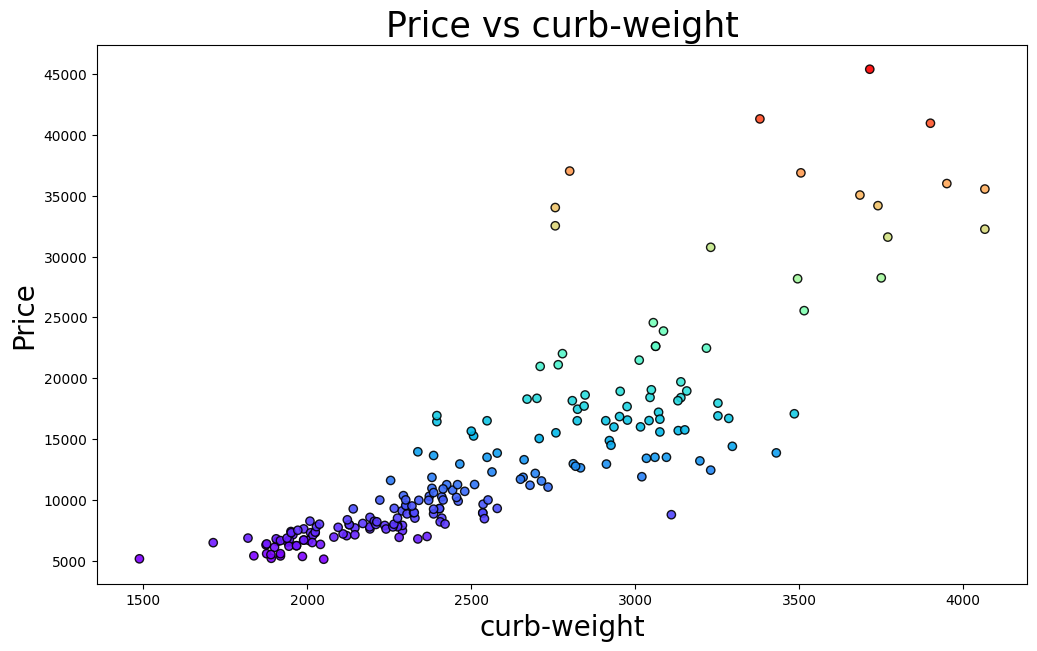

In [12]:
plt.figure(figsize=(12,7))
plt.scatter(
    df['curb-weight'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)

plt.xlabel('curb-weight', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.title('Price vs curb-weight', fontsize=25)
plt.show()

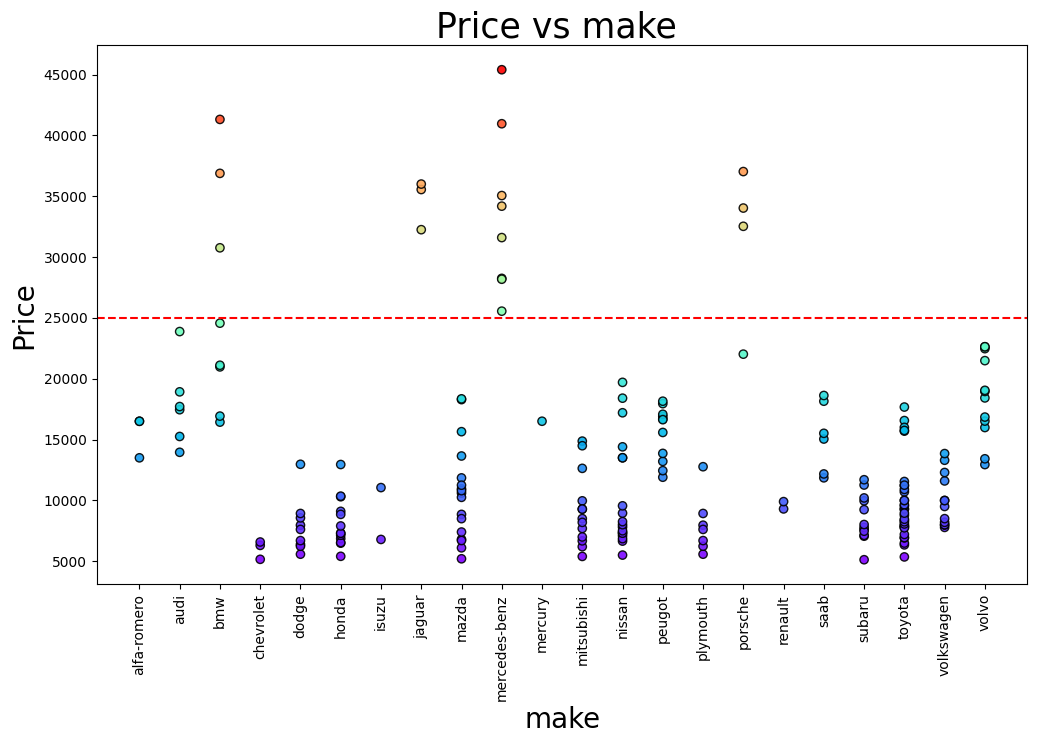

In [13]:
plt.figure(figsize=(12,7))
plt.scatter(
    df['make'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)
plt.xticks(rotation=90, ha='center')
plt.axhline(25000, color = 'red', linestyle = '--')

plt.xlabel('make', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.title('Price vs make ', fontsize=25)
plt.show()

### mercedes and jaguar car price uper then 25000.
### bmw and peugot car price 15000 to 4000
### other brand car price below 25000

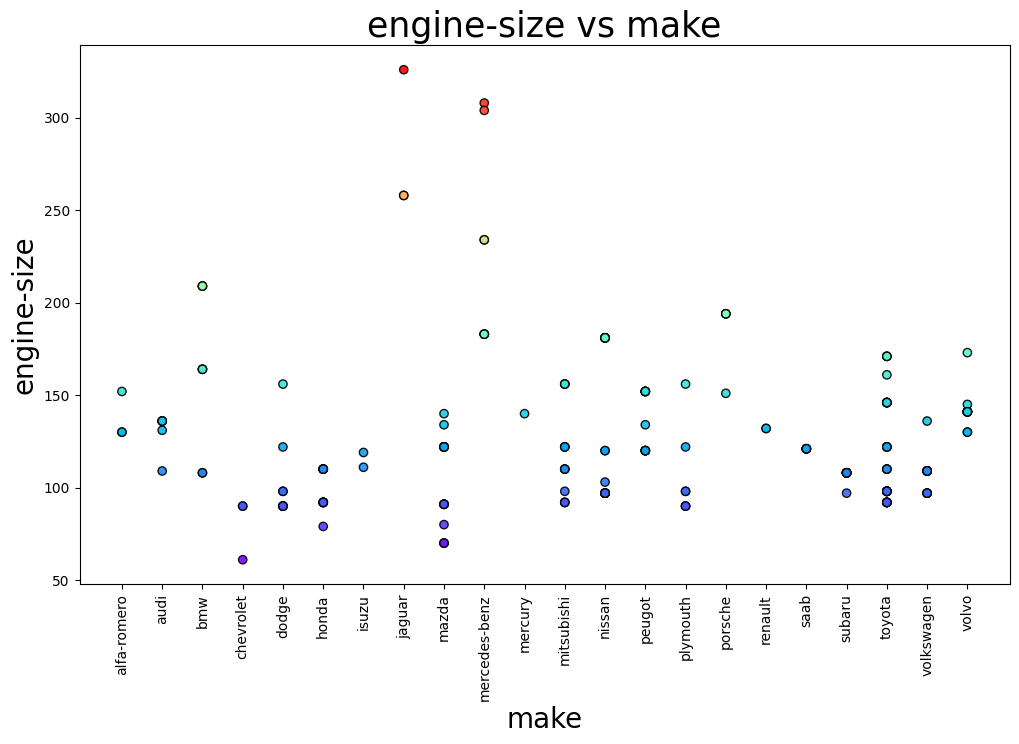

In [14]:
plt.figure(figsize=(12,7))
plt.scatter(
    df['make'],
    df['engine-size'],
    c= df['engine-size'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)
plt.xticks(rotation=90, ha='center')
plt.xlabel('make', fontsize=20)
plt.ylabel('engine-size', fontsize=20)
plt.title('engine-size vs make', fontsize=25)
plt.show()

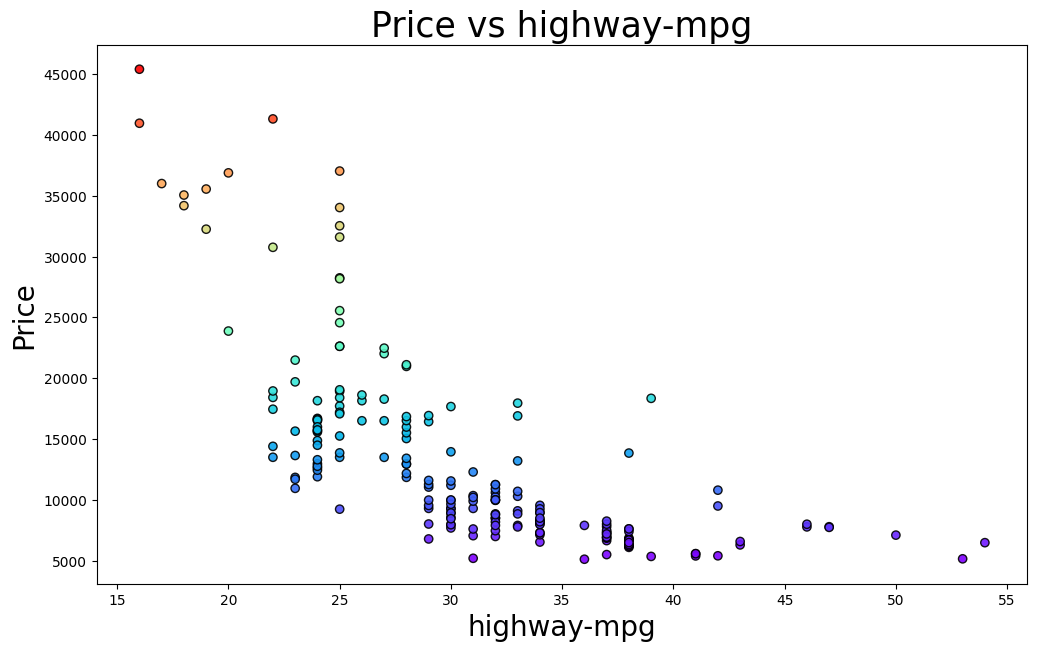

In [15]:
plt.figure(figsize=(12,7))
plt.scatter(
    df['highway-mpg'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)
plt.xlabel('highway-mpg', fontsize=20)
plt.ylabel('Price', fontsize=20)
plt.title('Price vs highway-mpg', fontsize=25)
plt.show()

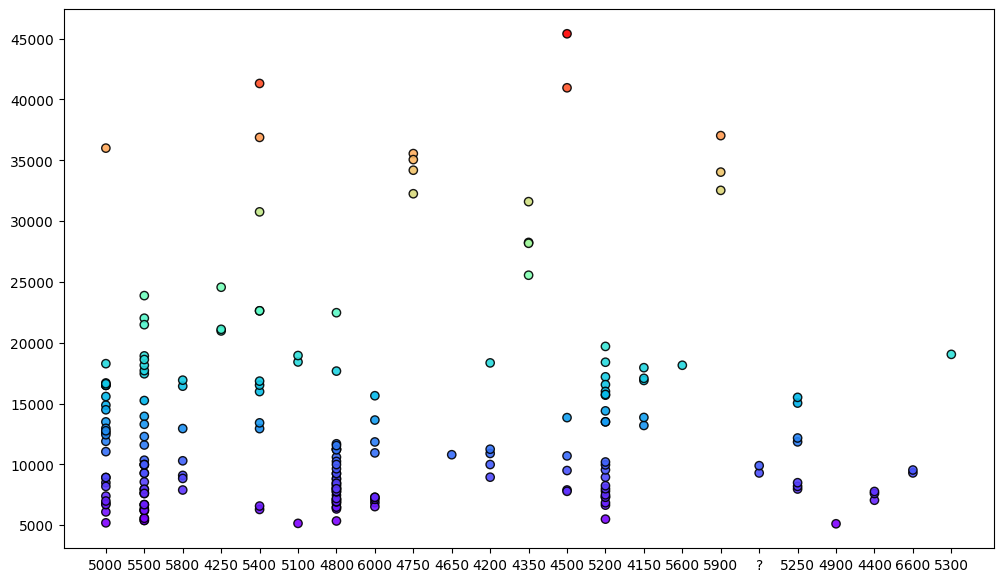

In [16]:
plt.figure(figsize=(12,7))

plt.scatter(
    df['peak-rpm'],
    df['price'],
    c= df['price'],
    cmap='rainbow',
    alpha=.90,
    edgecolors='k',
)

<Axes: xlabel='num-of-cylinders', ylabel='Count'>

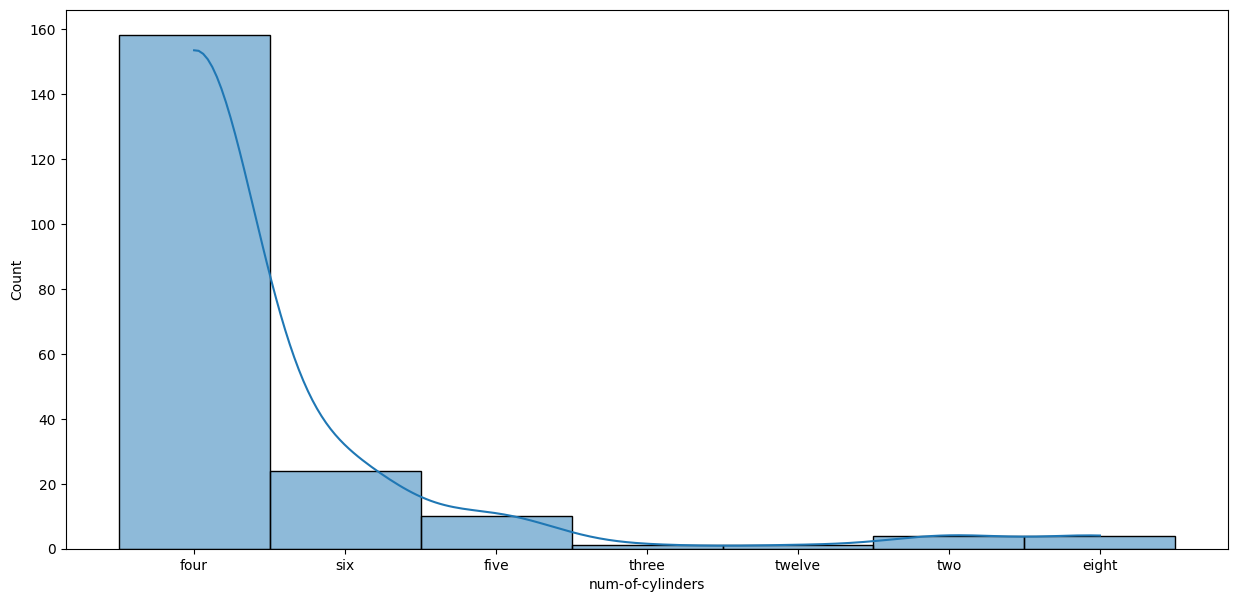

In [17]:
plt.figure(figsize=(15,7))
sns.histplot(df['num-of-cylinders'], kde=True,bins=50)

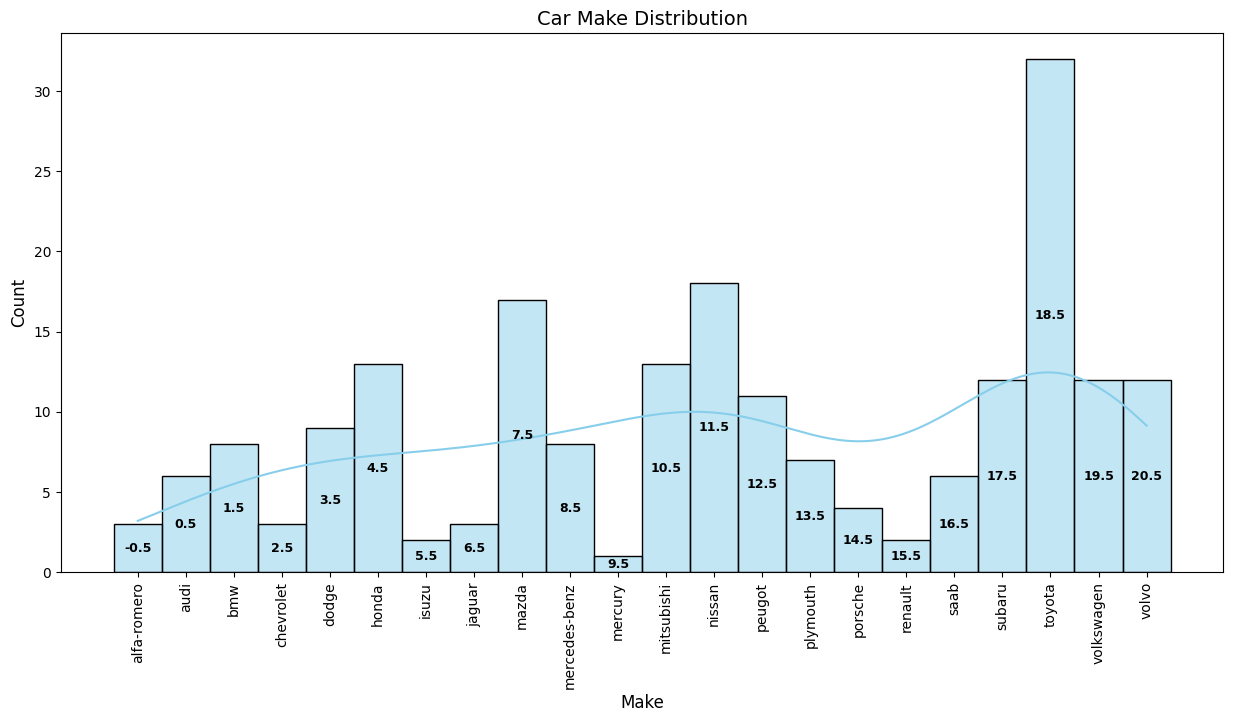

In [18]:
plt.figure(figsize=(15,7))
ax = sns.histplot(df['make'], kde=True, bins=50, color='skyblue')
plt.xticks(rotation=90, ha='center')  

for p in ax.patches:  
    height = p.get_height()               
    x_center = p.get_x() + p.get_width()/2  

    if height > 0:
        ax.text(
            x_center, 
            height/2,                     
            p.get_x(),                   
            ha='center', va='center', 
            fontsize=9, color='black', fontweight='bold'
        )

# Optional: adjust ticks and labels
plt.xticks(rotation=90, ha='center')
plt.xlabel('Make', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Car Make Distribution', fontsize=14)
plt.show()

<Axes: xlabel='body-style', ylabel='Count'>

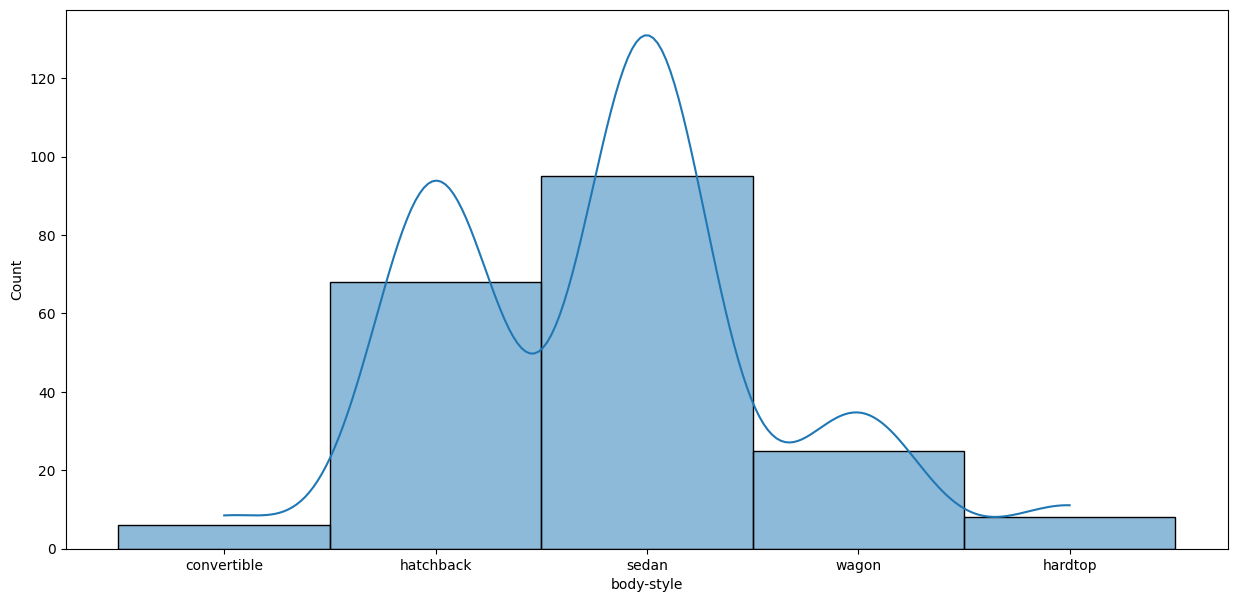

In [19]:
plt.figure(figsize=(15,7))
sns.histplot(df['body-style'], kde=True,bins=50)

<Axes: xlabel='drive-wheels', ylabel='Count'>

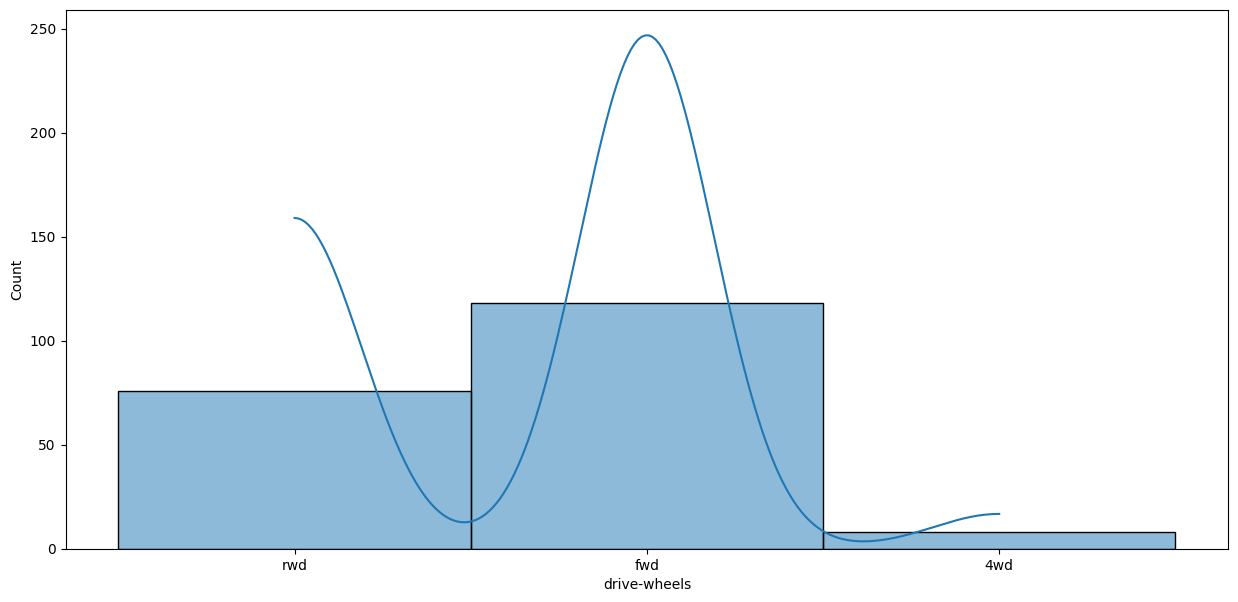

In [20]:
plt.figure(figsize=(15,7))
sns.histplot(df['drive-wheels'], kde=True,bins=50)

<Axes: xlabel='engine-type', ylabel='Count'>

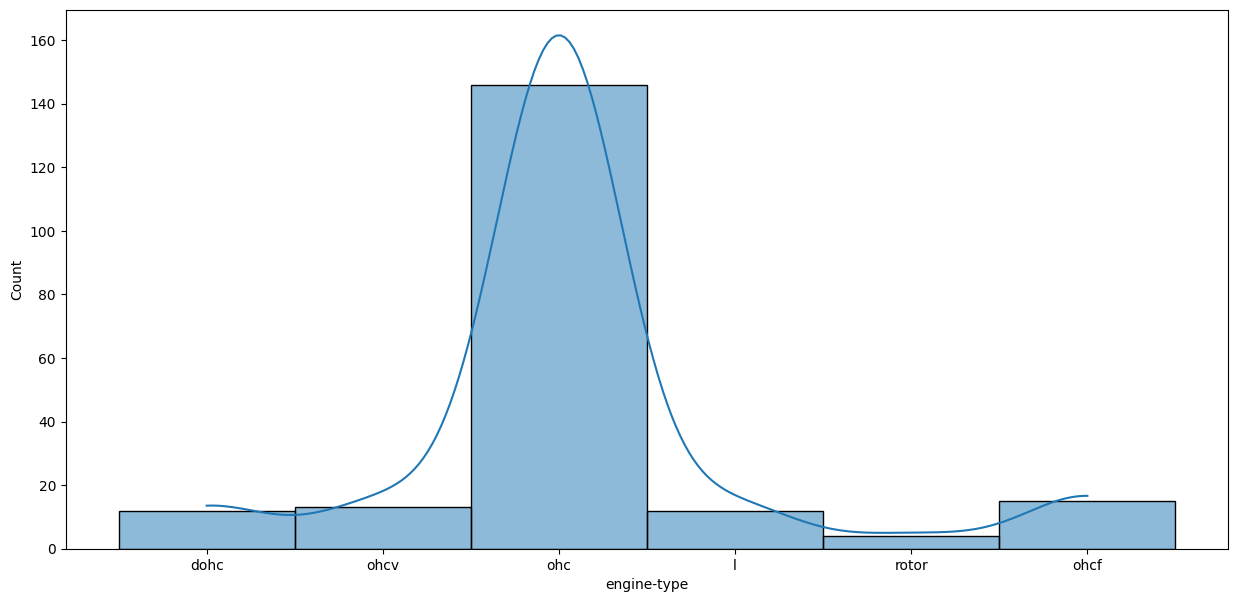

In [21]:
plt.figure(figsize=(15,7))
sns.histplot(df['engine-type'], kde=True,bins=50)

<Axes: xlabel='fuel-system', ylabel='Count'>

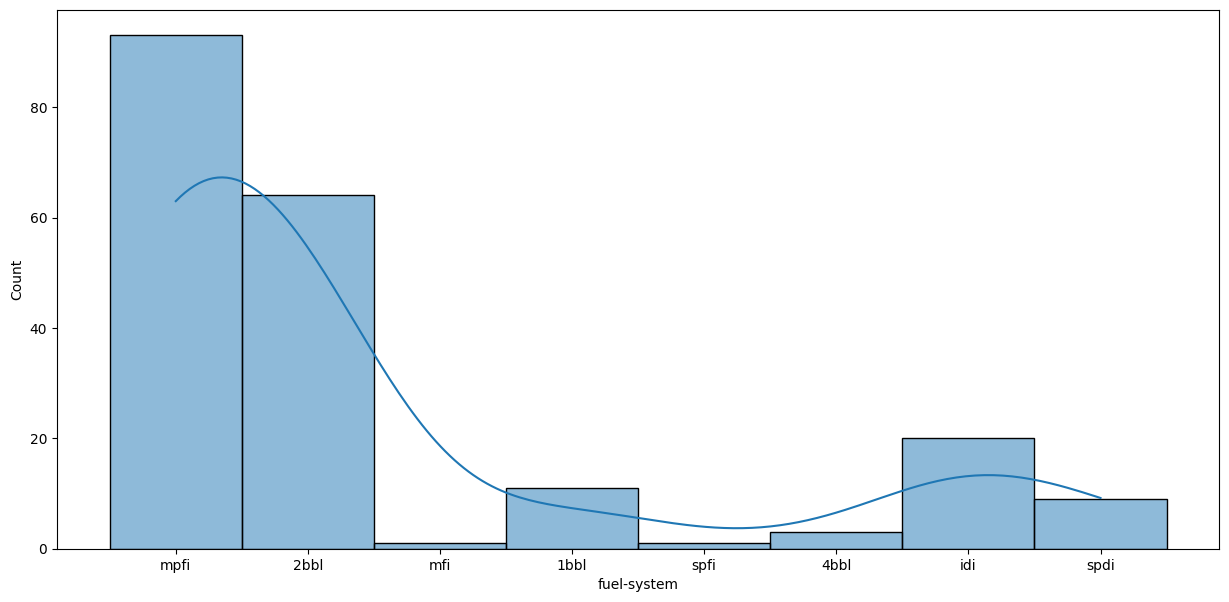

In [22]:
plt.figure(figsize=(15,7))
sns.histplot(df['fuel-system'], kde=True,bins=50)

<Axes: xlabel='fuel-type', ylabel='count'>

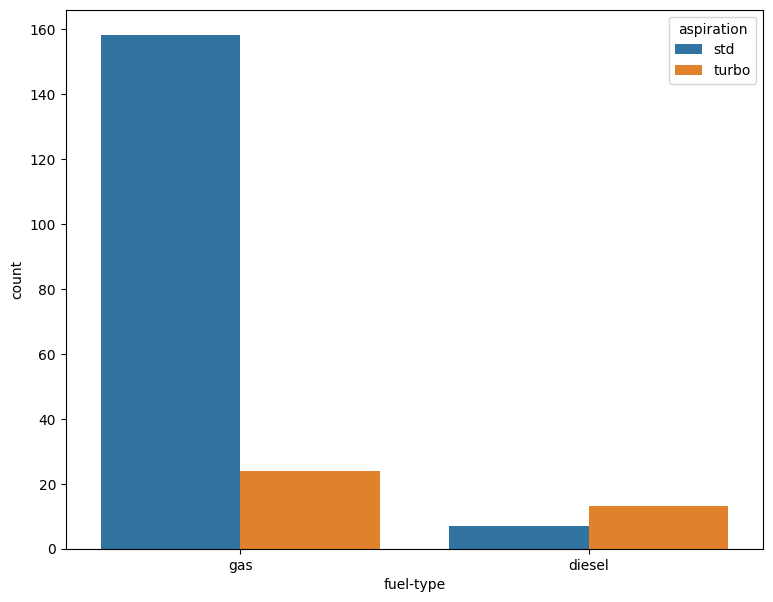

In [23]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'fuel-type', hue= 'aspiration',data=df)

<Axes: xlabel='engine-location', ylabel='count'>

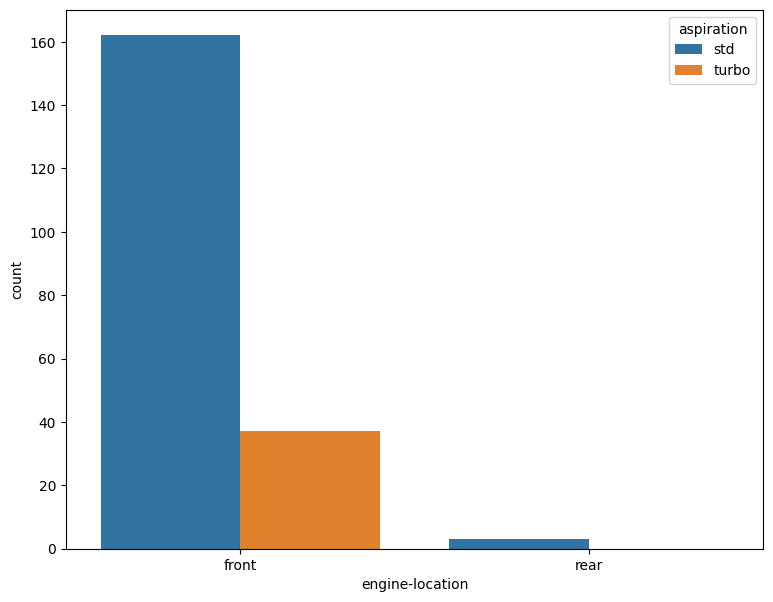

In [24]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'engine-location', hue= 'aspiration',data=df)

<Axes: xlabel='num-of-cylinders', ylabel='count'>

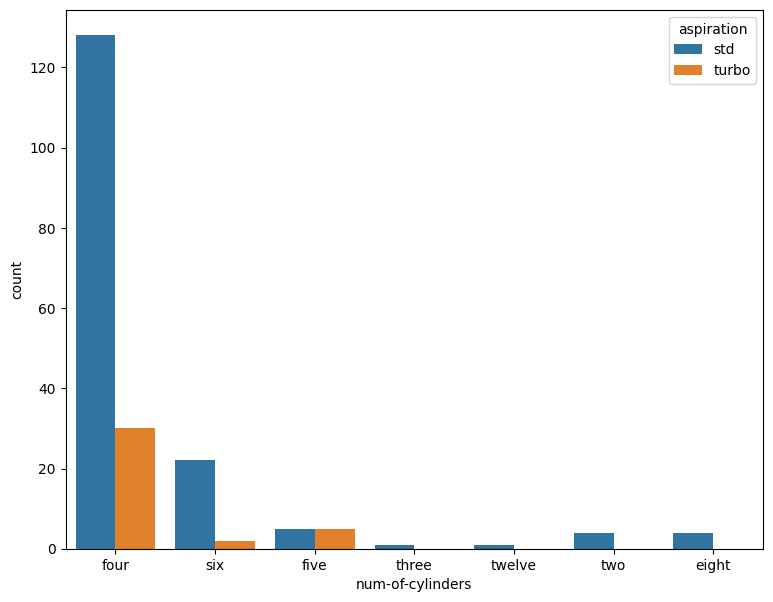

In [25]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'num-of-cylinders', hue= 'aspiration',data=df)

<Axes: xlabel='engine-type', ylabel='count'>

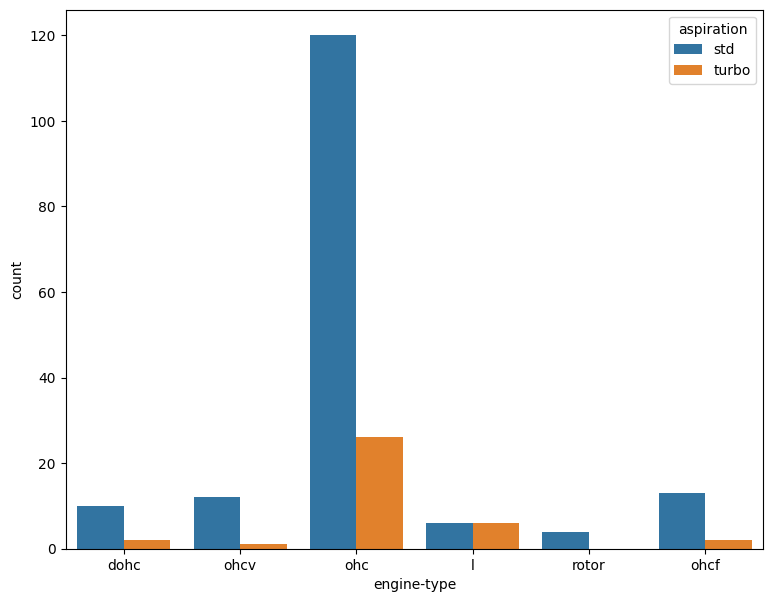

In [26]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'engine-type', hue= 'aspiration',data=df)

<Axes: xlabel='fuel-system', ylabel='count'>

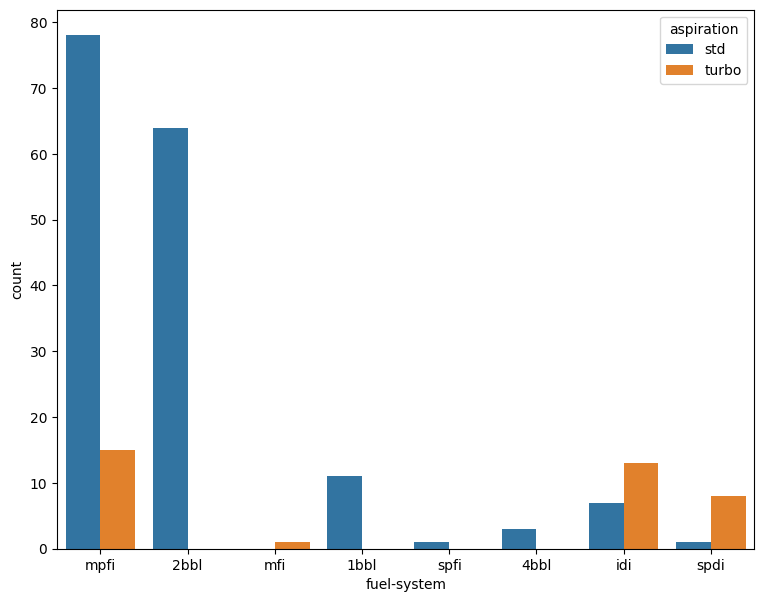

In [27]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'fuel-system', hue= 'aspiration',data=df)

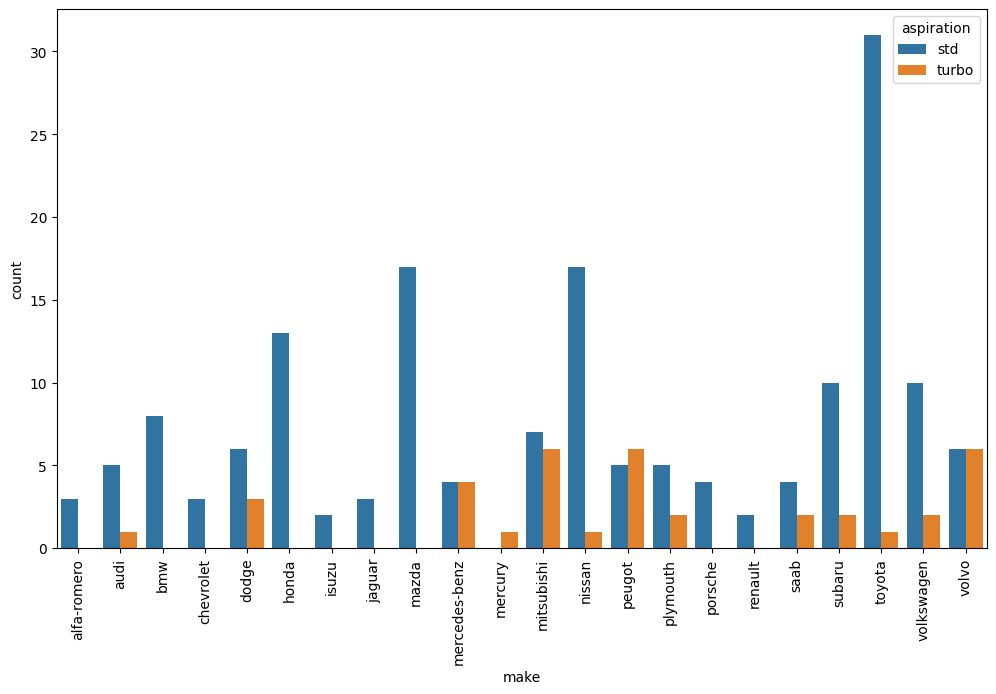

In [28]:
plt.figure(figsize=(12,7))
sns.countplot(x = 'make', hue= 'aspiration',data=df)
plt.xticks(rotation=90, ha='center')
plt.show()

<Axes: xlabel='drive-wheels', ylabel='count'>

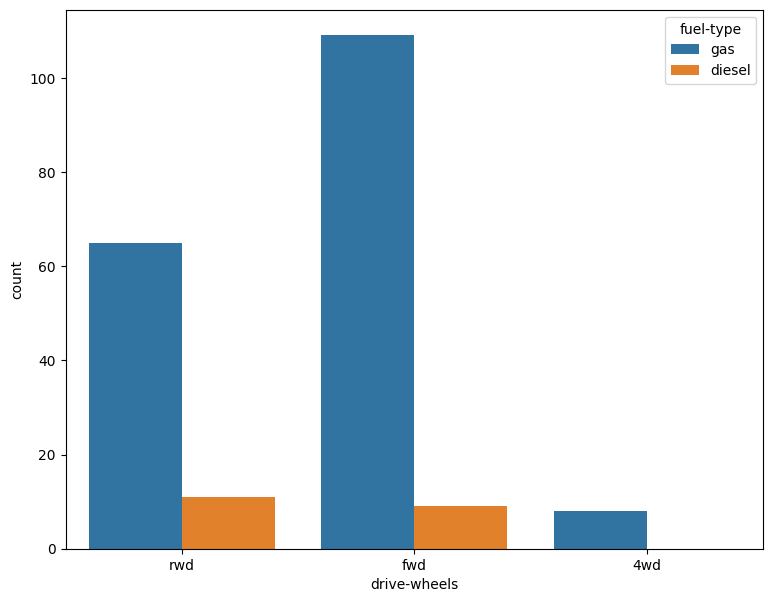

In [29]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'drive-wheels', hue= 'fuel-type',data=df)

<Axes: xlabel='num-of-doors', ylabel='count'>

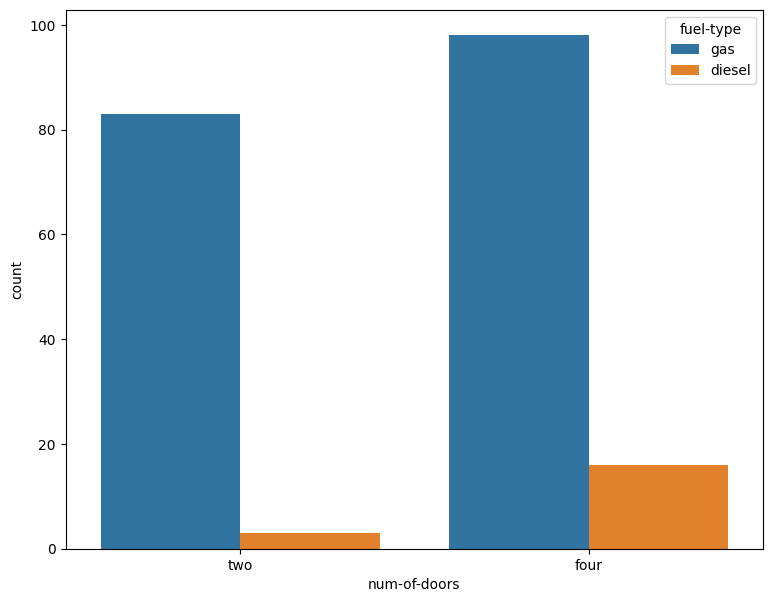

In [30]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'num-of-doors', hue= 'fuel-type',data=df)

<Axes: xlabel='engine-location', ylabel='count'>

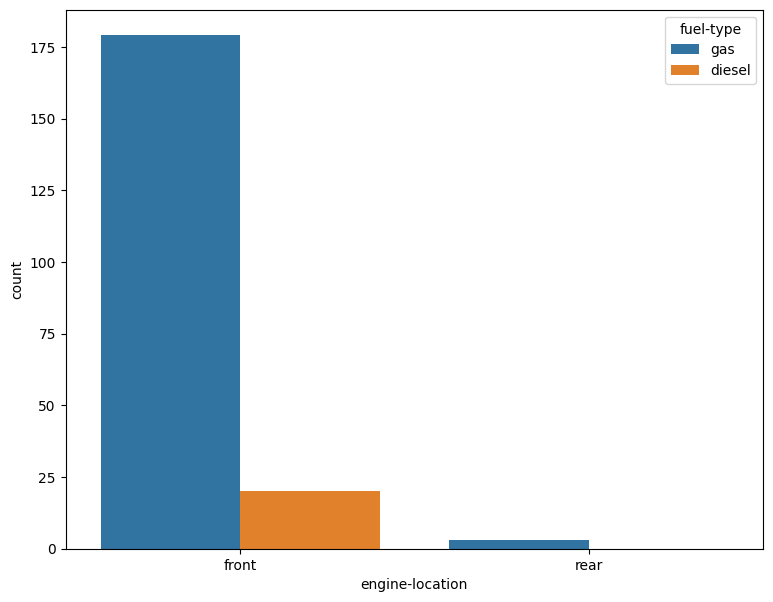

In [31]:
plt.figure(figsize=(9,7))
sns.countplot(x = 'engine-location', hue= 'fuel-type',data=df)

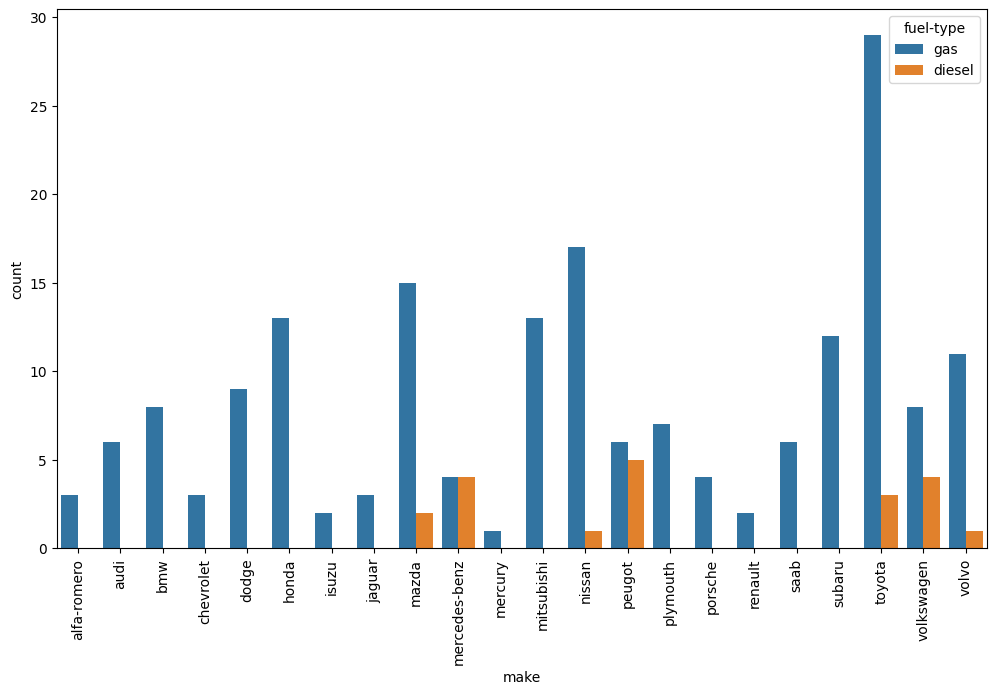

In [32]:
plt.figure(figsize=(12,7))
sns.countplot(x = 'make', hue= 'fuel-type',data=df)
plt.xticks(rotation=90, ha='center')
plt.show()

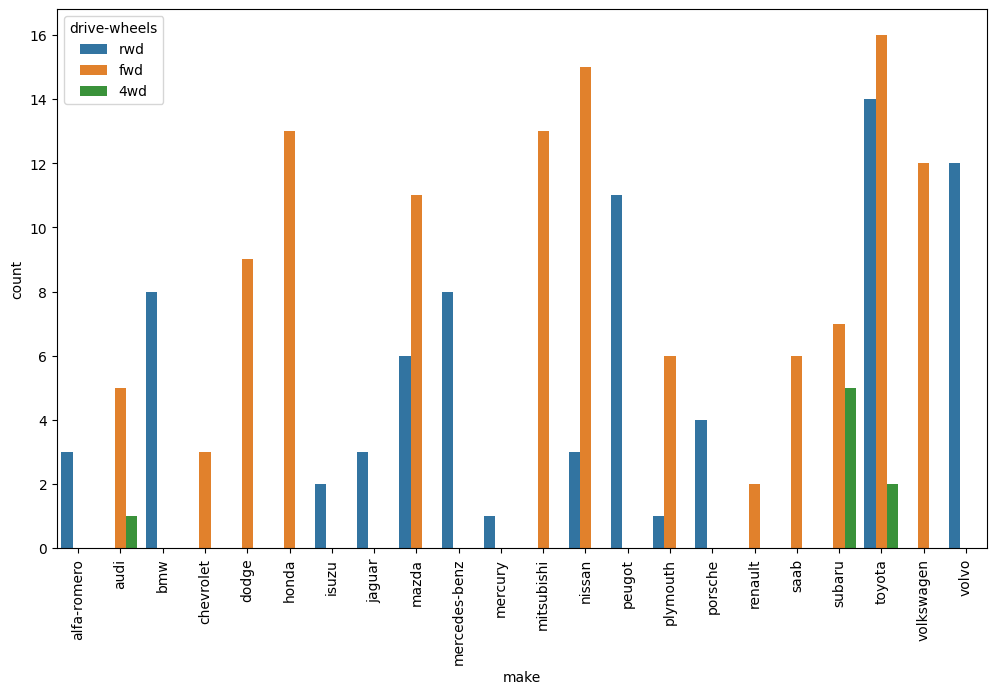

In [33]:
plt.figure(figsize=(12,7))
sns.countplot(x = 'make', hue= 'drive-wheels',data=df)
plt.xticks(rotation=90, ha='center')
plt.show()

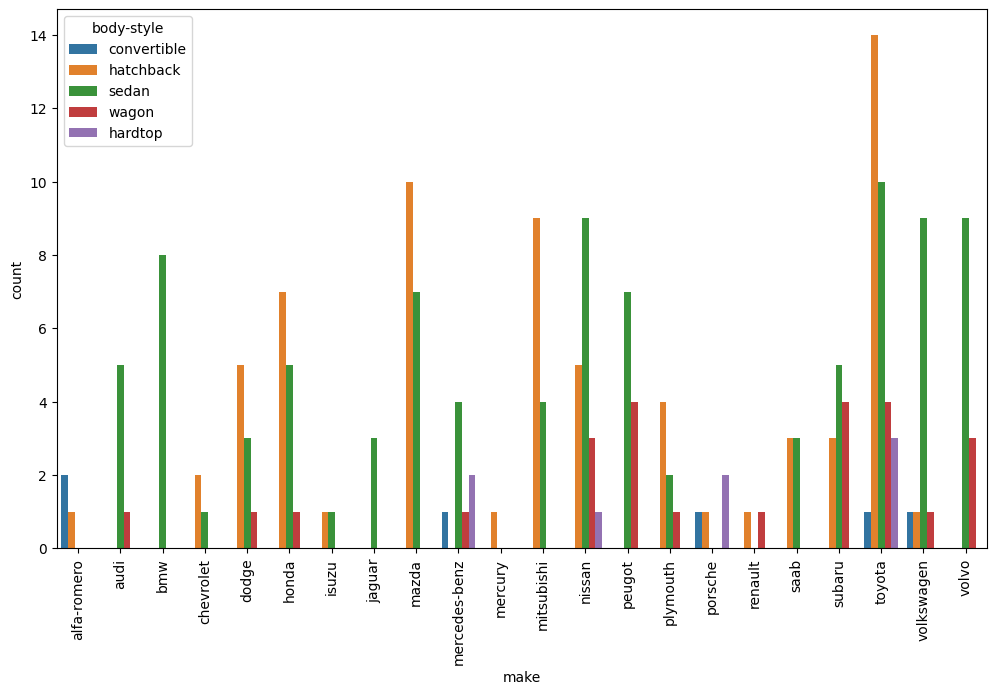

In [34]:
plt.figure(figsize=(12,7))
sns.countplot(x = 'make', hue= 'body-style',data=df)
plt.xticks(rotation=90, ha='center')
plt.show()

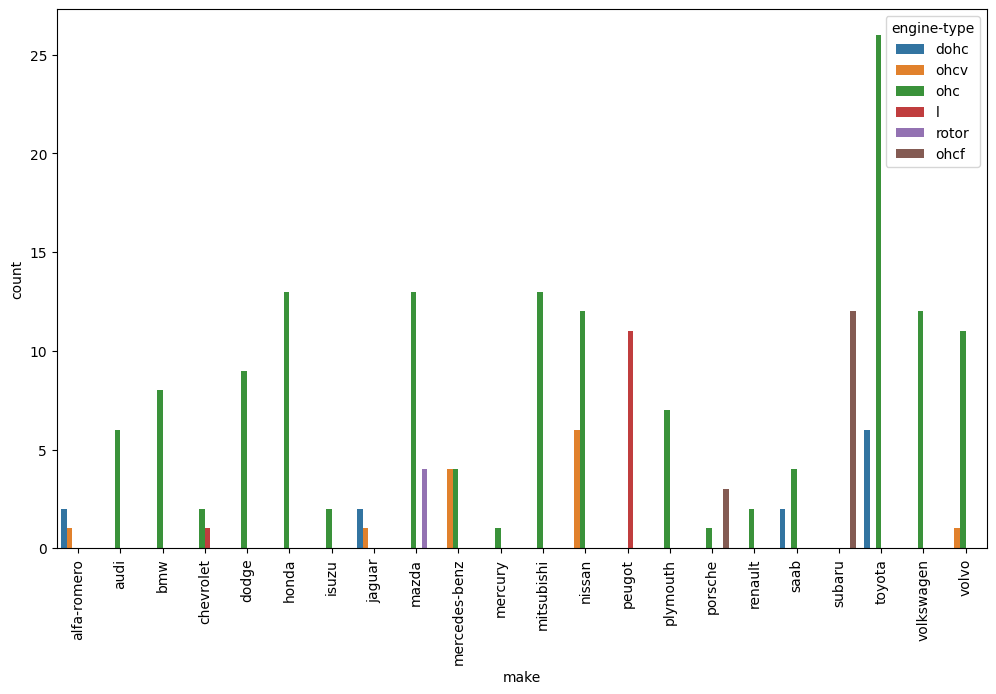

In [35]:

plt.figure(figsize=(12,7))
sns.countplot(x = 'make', hue= 'engine-type',data=df)
plt.xticks(rotation=90, ha='center')
plt.show()

In [36]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500,18,22,17450


In [37]:
df['normalized-losses'].mean()

np.float64(121.83636363636364)

In [38]:
median = df['normalized-losses'].median()

In [39]:
df['normalized-losses'] = df['normalized-losses'].fillna(median)
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,13495
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000,21,27,16500
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000,19,26,16500
3,2,164.0,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102.0,5500,24,30,13950
4,2,164.0,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115.0,5500,18,22,17450


In [40]:
df.applymap(lambda x: isinstance(x, str)).any()

symboling            False
normalized-losses    False
make                  True
fuel-type             True
aspiration            True
num-of-doors          True
body-style            True
drive-wheels          True
engine-location       True
wheel-base           False
length               False
width                False
height               False
curb-weight          False
engine-type           True
num-of-cylinders      True
engine-size          False
fuel-system           True
bore                  True
stroke                True
compression-ratio    False
horsepower           False
peak-rpm              True
city-mpg             False
highway-mpg          False
price                False
dtype: bool

In [41]:
df['peak-rpm'].unique()

array(['5000', '5500', '5800', '4250', '5400', '5100', '4800', '6000',
       '4750', '4650', '4200', '4350', '4500', '5200', '4150', '5600',
       '5900', '?', '5250', '4900', '4400', '6600', '5300'], dtype=object)

In [42]:
df= df.replace(['?','nan'],pd.NA)
df = df.apply(pd.to_numeric, errors='ignore')

In [43]:
df[20:30]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
20,1,118.0,dodge,gas,std,two,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.41,68.0,5500.0,37,41,5572
21,1,118.0,dodge,gas,std,two,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,6377
22,1,118.0,dodge,gas,turbo,two,hatchback,fwd,front,93.7,...,98,mpfi,3.03,3.39,7.60,102.0,5500.0,24,30,7957
23,1,148.0,dodge,gas,std,four,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,6229
24,1,148.0,dodge,gas,std,four,sedan,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,6692
25,1,148.0,dodge,gas,std,four,sedan,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,7609
26,1,148.0,dodge,gas,turbo,NaN,sedan,fwd,front,93.7,...,98,mpfi,3.03,3.39,7.60,102.0,5500.0,24,30,8558
27,-1,110.0,dodge,gas,std,four,wagon,fwd,front,103.3,...,122,2bbl,3.34,3.46,8.50,88.0,5000.0,24,30,8921
28,3,145.0,dodge,gas,turbo,two,hatchback,fwd,front,95.9,...,156,mfi,3.60,3.90,7.00,145.0,5000.0,19,24,12964
29,2,137.0,honda,gas,std,two,hatchback,fwd,front,86.6,...,92,1bbl,2.91,3.41,9.60,58.0,4800.0,49,54,6479


In [44]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 4
stroke               4
compression-ratio    0
horsepower           2
peak-rpm             2
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [45]:
bore_mean = df.bore.mean()
df.bore = df.bore.fillna(bore_mean)

In [46]:
stroke_mean = df.stroke.mean()
df.stroke = df.stroke.fillna(stroke_mean)

In [47]:
peak_rpm_mean =df['peak-rpm'].mean()

In [48]:
df['peak-rpm'] = df['peak-rpm'].fillna(peak_rpm_mean)

In [49]:
horsepower_median = df.horsepower.median()
df.horsepower = df.horsepower.fillna(horsepower_median)


In [50]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         2
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [51]:
df['num-of-doors'].unique()

array(['two', 'four', nan], dtype=object)

In [52]:
df['num-of-doors']= df['num-of-doors'].replace(['two', 'four'],[2,4])

In [53]:
df['num-of-doors'].median()

np.float64(4.0)

In [54]:
num_of_median = df['num-of-doors'].median()

In [55]:
df['num-of-doors'] = df['num-of-doors'].fillna(num_of_median)

In [57]:
df[20:30]

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
20,1,118.0,dodge,gas,std,2.0,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.41,68.0,5500.0,37,41,5572
21,1,118.0,dodge,gas,std,2.0,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,6377
22,1,118.0,dodge,gas,turbo,2.0,hatchback,fwd,front,93.7,...,98,mpfi,3.03,3.39,7.60,102.0,5500.0,24,30,7957
23,1,148.0,dodge,gas,std,4.0,hatchback,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,6229
24,1,148.0,dodge,gas,std,4.0,sedan,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,6692
25,1,148.0,dodge,gas,std,4.0,sedan,fwd,front,93.7,...,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38,7609
26,1,148.0,dodge,gas,turbo,4.0,sedan,fwd,front,93.7,...,98,mpfi,3.03,3.39,7.60,102.0,5500.0,24,30,8558
27,-1,110.0,dodge,gas,std,4.0,wagon,fwd,front,103.3,...,122,2bbl,3.34,3.46,8.50,88.0,5000.0,24,30,8921
28,3,145.0,dodge,gas,turbo,2.0,hatchback,fwd,front,95.9,...,156,mfi,3.60,3.90,7.00,145.0,5000.0,19,24,12964
29,2,137.0,honda,gas,std,2.0,hatchback,fwd,front,86.6,...,92,1bbl,2.91,3.41,9.60,58.0,4800.0,49,54,6479


# train- test

In [58]:
x_df = df.drop('price',axis=1)
y_df = df['price']

In [59]:
xtrain, xtest, ytrain, ytest = train_test_split(x_df,y_df, test_size=.25,random_state=1)

# only label encodeing

In [60]:
xtrain.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,-1,65.0,toyota,gas,std,4.0,sedan,fwd,front,102.4,...,four,122,mpfi,3.31000,3.540000,8.7,92.0,4200.0,29,34
151,0,91.0,toyota,gas,std,4.0,wagon,4wd,front,95.7,...,four,92,2bbl,3.05000,3.030000,9.0,62.0,4800.0,27,32
89,1,122.0,nissan,gas,std,4.0,sedan,fwd,front,94.5,...,four,97,2bbl,3.15000,3.290000,9.4,69.0,5200.0,31,37
186,3,256.0,volkswagen,gas,std,2.0,hatchback,fwd,front,94.5,...,four,109,mpfi,3.19000,3.400000,8.5,90.0,5500.0,24,29
53,3,150.0,mazda,gas,std,2.0,hatchback,rwd,front,95.3,...,two,70,4bbl,3.33298,3.256364,9.4,101.0,6000.0,17,23


In [61]:
from pandas.core.dtypes.common import is_numeric_dtype

# Dictionary to store encoders for each column
encoders = {}

for col in xtrain.columns:
    if is_numeric_dtype(xtrain[col]):
        continue
    else:
        # Create a new encoder for each column
        encoders[col] = LabelEncoder()
        
        # Fit on training data
        xtrain[col] = encoders[col].fit_transform(xtrain[col])
        
        # Handle unknown labels in test set
        test_values = xtest[col].values
        encoded_test = []
        
        for val in test_values:
            if val in encoders[col].classes_:
                encoded_test.append(encoders[col].transform([val])[0])
            else:
                # Assign a special value for unknown categories (e.g., -1 or max+1)
                encoded_test.append(-1)
        
        xtest[col] = encoded_test

In [62]:
xtrain.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,-1,65.0,19,1,0,4.0,3,1,0,102.4,...,2,122,4,3.31000,3.540000,8.7,92.0,4200.0,29,34
151,0,91.0,19,1,0,4.0,4,0,0,95.7,...,2,92,1,3.05000,3.030000,9.0,62.0,4800.0,27,32
89,1,122.0,12,1,0,4.0,3,1,0,94.5,...,2,97,1,3.15000,3.290000,9.4,69.0,5200.0,31,37
186,3,256.0,20,1,0,2.0,2,1,0,94.5,...,2,109,4,3.19000,3.400000,8.5,90.0,5500.0,24,29
53,3,150.0,8,1,0,2.0,2,2,0,95.3,...,6,70,2,3.33298,3.256364,9.4,101.0,6000.0,17,23


In [63]:
xtest.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
196,-1,95.0,21,1,0,4.0,3,2,0,109.1,...,2,141,4,3.78,3.15,9.5,114.0,5400.0,23,28
95,2,168.0,12,1,0,2.0,1,1,0,95.1,...,2,97,1,3.15,3.29,9.4,69.0,5200.0,31,37
173,-1,65.0,19,1,0,4.0,2,1,0,102.4,...,2,122,4,3.31,3.54,8.7,92.0,4200.0,27,32
123,3,115.0,15,1,0,2.0,1,2,1,89.5,...,3,194,4,3.74,2.90,9.5,207.0,5900.0,17,25
38,0,85.0,5,1,0,4.0,3,1,0,96.5,...,2,110,0,3.15,3.58,9.0,86.0,5800.0,27,33


# Normalization

In [64]:
mms = MinMaxScaler()

In [65]:
xtrain_mms = mms.fit_transform(xtrain)

In [66]:
xtrain_nor = pd.DataFrame(xtrain_mms, columns=xtrain.columns, index= xtrain.index)
xtrain_nor.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,0.2,0.000000,0.904762,1.0,0.0,1.0,0.75,0.5,0.0,0.460641,...,0.333333,0.230189,0.666667,0.611111,0.700000,0.10625,0.205607,0.020408,0.470588,0.486486
151,0.4,0.136126,0.904762,1.0,0.0,1.0,1.00,0.0,0.0,0.265306,...,0.333333,0.116981,0.166667,0.404762,0.457143,0.12500,0.065421,0.265306,0.411765,0.432432
89,0.6,0.298429,0.571429,1.0,0.0,1.0,0.75,0.5,0.0,0.230321,...,0.333333,0.135849,0.166667,0.484127,0.580952,0.15000,0.098131,0.428571,0.529412,0.567568
186,1.0,1.000000,0.952381,1.0,0.0,0.0,0.50,0.5,0.0,0.230321,...,0.333333,0.181132,0.666667,0.515873,0.633333,0.09375,0.196262,0.551020,0.323529,0.351351
53,1.0,0.445026,0.380952,1.0,0.0,0.0,0.50,1.0,0.0,0.253644,...,1.000000,0.033962,0.333333,0.629349,0.564935,0.15000,0.247664,0.755102,0.117647,0.189189


In [67]:
xtest_mms = mms.transform(xtest)
xtest_nor = pd.DataFrame(xtest_mms, columns= xtest.columns, index= xtest.index)

# linear regression

In [68]:
linear_model = LinearRegression()

In [69]:
linear_model.fit(xtrain_nor,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [70]:
linear_model.score(xtrain_nor,ytrain)

0.9007506146077746

In [71]:
linear_model.score(xtest_nor,ytest)

0.8599270975272066

In [72]:
ypred=linear_model.predict(xtest_nor)

In [75]:
mse = mean_squared_error(ytest,ypred)
mse

8160808.750045175

In [76]:
mae = mean_absolute_error(ytest, ypred)
mae

2132.267663659643

In [78]:
lasso_model = Lasso()
lasso_model.fit(xtrain_nor, ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [79]:
lasso_model.score(xtest_nor,ytest)

0.8605484471831903

In [80]:
ypred=lasso_model.predict(xtest_nor)

In [81]:
mse = mean_squared_error(ytest,ypred)
mse

8124608.202902418

In [82]:
mae = mean_absolute_error(ytest, ypred)
mae

2131.8202524126455

In [83]:
from sklearn.neighbors import KNeighborsClassifier

In [84]:
kn_cl = KNeighborsClassifier(n_neighbors=5)

In [85]:
kn_cl.fit(xtrain_nor,ytrain)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [86]:
kn_cl.score(xtest_nor,ytest)

0.0

In [87]:
kn_cl.score(xtrain_nor,ytrain)

0.15894039735099338

In [88]:
from sklearn.neighbors import KNeighborsRegressor

In [92]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)

In [93]:
kn_re.fit(xtrain_nor,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [94]:
kn_re.score(xtest_nor,ytest)

0.9318655355176015

In [ ]:
kn_re.score(xtrain_nor,ytrain)

In [95]:
ypred=kn_re.predict(xtest_nor)

In [96]:
mse = mean_squared_error(ytest,ypred)
mse

3969592.434451043

In [97]:
mae = mean_absolute_error(ytest, ypred)
mae

1392.4575828715715

# standardization

In [98]:
std = StandardScaler()

In [99]:
xtrain_s = std.fit_transform(xtrain)

In [100]:
xtrain_std = pd.DataFrame(xtrain_s, columns= xtrain.columns, index= xtrain.index)
xtrain_std.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,-1.468406,-1.739653,1.007245,0.356182,-0.48755,0.893095,0.453792,-0.653098,-0.115857,0.590085,...,-0.168574,-0.103479,0.783085,-0.100654,0.984230,-0.395394,-0.297992,-1.869260,0.616029,0.493844
151,-0.676516,-0.936988,1.007245,0.356182,-0.48755,0.893095,1.615193,-2.446149,-0.115857,-0.508938,...,-0.168574,-0.807319,-1.209823,-1.057030,-0.625545,-0.324323,-1.099599,-0.627373,0.299094,0.200837
89,0.115375,0.020036,-0.114628,0.356182,-0.48755,0.893095,0.453792,-0.653098,-0.115857,-0.705778,...,-0.168574,-0.690012,-1.209823,-0.689193,0.195124,-0.229561,-0.912557,0.200553,0.932963,0.933356
186,1.699155,4.156848,1.167512,0.356182,-0.48755,-1.119701,-0.707609,-0.653098,-0.115857,-0.705778,...,-0.168574,-0.408476,0.783085,-0.542058,0.542331,-0.442774,-0.351433,0.821496,-0.176308,-0.238675
53,1.699155,0.884444,-0.755699,0.356182,-0.48755,-1.119701,-0.707609,1.139953,-0.115857,-0.574551,...,4.459541,-1.323469,-0.545520,-0.016126,0.088954,-0.229561,-0.057510,1.856403,-1.285579,-1.117699


In [101]:
xtest_s = std.transform(xtest)
xtest_std = pd.DataFrame(xtest_s, columns= xtest.columns, index= xtest.index)
xtest_std.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
196,-1.468406,-0.813501,1.327780,0.356182,-0.48755,0.893095,0.453792,1.139953,-0.115857,1.689108,...,-0.168574,0.342287,0.783085,1.628180,-0.246775,-0.205871,0.289852,0.614515,-0.334775,-0.385179
95,0.907265,1.440136,-0.114628,0.356182,-0.48755,-1.119701,-1.869010,-0.653098,-0.115857,-0.607358,...,-0.168574,-0.690012,-1.209823,-0.689193,0.195124,-0.229561,-0.912557,0.200553,0.932963,0.933356
173,-1.468406,-1.739653,1.007245,0.356182,-0.48755,0.893095,-0.707609,-0.653098,-0.115857,0.590085,...,-0.168574,-0.103479,0.783085,-0.100654,0.984230,-0.395394,-0.297992,-1.869260,0.299094,0.200837
123,1.699155,-0.196066,0.366174,0.356182,-0.48755,-1.119701,-1.869010,1.139953,8.631338,-1.525944,...,0.988455,1.585739,0.783085,1.481045,-1.035880,-0.205871,2.774832,1.649421,-1.285579,-0.824691
38,-0.676516,-1.122218,-1.236502,0.356182,-0.48755,0.893095,0.453792,-0.653098,-0.115857,-0.377711,...,-0.168574,-0.385015,-1.874126,-0.689193,1.110487,-0.324323,-0.458314,1.442440,0.299094,0.347340


In [105]:
linear_model.fit(xtrain_std,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [103]:
linear_model.score(xtest_std,ytest)

0.8599270975272063

In [106]:
ypred=linear_model.predict(xtest_std)

In [107]:
mse = mean_squared_error(ytest, ypred)
mse

8160808.750045197

In [108]:
mae = mean_absolute_error(ytest, ypred)
mae

2132.267663659643

In [109]:
lasso_model.fit(xtrain_std,ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [110]:
lasso_model.score(xtest_std,ytest)

0.8600888005779785

In [111]:
ypred=lasso_model.predict(xtest_std)

In [112]:
mse = mean_squared_error(ytest, ypred)
mse

8151387.74392371

In [113]:
mae = mean_absolute_error(ytest, ypred)
mae

2132.7465238617356

In [114]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)
kn_re.fit(xtrain_std,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [115]:
kn_re.score(xtest_std,ytest)

0.9356475866515641

In [116]:
ypred=kn_re.predict(xtest_std)

In [117]:
mse = mean_squared_error(ytest, ypred)
mse

3749245.776087523

In [118]:
mae = mean_absolute_error(ytest, ypred)
mae

1276.8859381901696

# Log function transformation

In [119]:
log_t = FunctionTransformer()
xtrain_l = log_t.fit_transform(xtrain)

In [120]:
xtrain_log = pd.DataFrame(xtrain_l, columns= xtrain.columns, index= xtrain.index)
xtrain_log.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,-1,65.0,19,1,0,4.0,3,1,0,102.4,...,2,122,4,3.31000,3.540000,8.7,92.0,4200.0,29,34
151,0,91.0,19,1,0,4.0,4,0,0,95.7,...,2,92,1,3.05000,3.030000,9.0,62.0,4800.0,27,32
89,1,122.0,12,1,0,4.0,3,1,0,94.5,...,2,97,1,3.15000,3.290000,9.4,69.0,5200.0,31,37
186,3,256.0,20,1,0,2.0,2,1,0,94.5,...,2,109,4,3.19000,3.400000,8.5,90.0,5500.0,24,29
53,3,150.0,8,1,0,2.0,2,2,0,95.3,...,6,70,2,3.33298,3.256364,9.4,101.0,6000.0,17,23


In [121]:
xtest_l = log_t.transform(xtest)
xtest_log = pd.DataFrame(xtest_l, columns=xtest.columns, index= xtest.index)
xtest_log.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
196,-1,95.0,21,1,0,4.0,3,2,0,109.1,...,2,141,4,3.78,3.15,9.5,114.0,5400.0,23,28
95,2,168.0,12,1,0,2.0,1,1,0,95.1,...,2,97,1,3.15,3.29,9.4,69.0,5200.0,31,37
173,-1,65.0,19,1,0,4.0,2,1,0,102.4,...,2,122,4,3.31,3.54,8.7,92.0,4200.0,27,32
123,3,115.0,15,1,0,2.0,1,2,1,89.5,...,3,194,4,3.74,2.90,9.5,207.0,5900.0,17,25
38,0,85.0,5,1,0,4.0,3,1,0,96.5,...,2,110,0,3.15,3.58,9.0,86.0,5800.0,27,33


In [122]:
linear_model.fit(xtrain_log,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
linear_model.score(xtest_log,ytest)

In [123]:
ypred= linear_model.predict(xtest_log)

In [124]:
mse = mean_squared_error(ytest, ypred)
mse

8160808.750045175

In [125]:
mae = mean_absolute_error(ytest, ypred)
mae

2132.267663659644

In [133]:
lasso_model.fit(xtrain_log,ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [134]:
lasso_model.score(xtest_log,ytest)

0.8600682355637179

In [135]:
ypred= lasso_model.predict(xtest_log)

In [136]:
mse = mean_squared_error(ytest, ypred)
mse

8152585.885358344

In [137]:
mae = mean_absolute_error(ytest, ypred)
mae

2131.116139090937

In [138]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)
kn_re.fit(xtrain_log,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [139]:
kn_re.score(xtest_log,ytest)

0.949490587773144

In [140]:
ypred= kn_re.predict(xtest_log)

In [141]:
mse = mean_squared_error(ytest, ypred)
mse

2942736.574910537

In [142]:
mae = mean_absolute_error(ytest, ypred)
mae

1240.733284075683

# Robust Scaler

In [143]:
rbs= RobustScaler()
xtrain_r = rbs.fit_transform(xtrain)

In [144]:
xtrain_rbs = pd.DataFrame(xtrain_r, columns= xtrain.columns, index= xtrain.index)
xtrain_rbs.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,-1.0,-1.063830,0.545455,0.0,0.0,0.0,0.0,0.0,0.0,0.683544,...,0.0,0.255814,0.000000,-0.052827,0.859504,-0.428571,-0.108696,-1.142857,0.454545,0.363636
151,-0.5,-0.510638,0.545455,0.0,0.0,0.0,1.0,-1.0,0.0,-0.164557,...,0.0,-0.441860,-1.000000,-0.650528,-0.685950,0.000000,-0.760870,-0.285714,0.272727,0.181818
89,0.0,0.148936,-0.090909,0.0,0.0,0.0,0.0,0.0,0.0,-0.316456,...,0.0,-0.325581,-1.000000,-0.420643,0.101928,0.571429,-0.608696,0.285714,0.636364,0.636364
186,1.0,3.000000,0.636364,0.0,0.0,-1.0,-1.0,0.0,0.0,-0.316456,...,0.0,-0.046512,0.000000,-0.328689,0.435262,-0.714286,-0.152174,0.714286,0.000000,-0.090909
53,1.0,0.744681,-0.454545,0.0,0.0,-1.0,-1.0,1.0,0.0,-0.215190,...,4.0,-0.953488,-0.666667,0.000000,0.000000,0.571429,0.086957,1.428571,-0.636364,-0.636364


In [145]:
xtest_r = rbs.transform(xtest)
xtest_rbs = pd.DataFrame(xtest_r, columns=xtest.columns, index= xtest.index)
xtest_rbs.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
196,-1.0,-0.425532,0.727273,0.0,0.0,0.0,0.0,1.0,0.0,1.531646,...,0.0,0.697674,0.000000,1.027633,-0.322314,0.714286,0.369565,0.571429,-0.090909,-0.181818
95,0.5,1.127660,-0.090909,0.0,0.0,-1.0,-2.0,0.0,0.0,-0.240506,...,0.0,-0.325581,-1.000000,-0.420643,0.101928,0.571429,-0.608696,0.285714,0.636364,0.636364
173,-1.0,-1.063830,0.545455,0.0,0.0,0.0,-1.0,0.0,0.0,0.683544,...,0.0,0.255814,0.000000,-0.052827,0.859504,-0.428571,-0.108696,-1.142857,0.272727,0.181818
123,1.0,0.000000,0.181818,0.0,0.0,-1.0,-2.0,1.0,1.0,-0.949367,...,1.0,1.930233,0.000000,0.935679,-1.079890,0.714286,2.391304,1.285714,-0.636364,-0.454545
38,-0.5,-0.638298,-0.727273,0.0,0.0,0.0,0.0,0.0,0.0,-0.063291,...,0.0,-0.023256,-1.333333,-0.420643,0.980716,0.000000,-0.239130,1.142857,0.272727,0.272727


In [146]:
linear_model.fit(xtrain_rbs,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [147]:
linear_model.score(xtest_rbs,ytest)

0.8599270975272066

In [148]:
ypred= linear_model.predict(xtest_rbs)

In [149]:
mse = mean_squared_error(ytest, ypred)
mse

8160808.75004518

In [150]:
mae = mean_absolute_error(ytest, ypred)
mae

2132.267663659642

In [151]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)
kn_re.fit(xtrain_rbs,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [152]:
kn_re.score(xtest_rbs,ytest)

0.9177001462558527

In [153]:
ypred= kn_re.predict(xtest_rbs)

In [154]:
mse = mean_squared_error(ytest, ypred)
mse

4794884.3402679395

In [155]:
mae = mean_absolute_error(ytest, ypred)
mae

1463.5199411295844

# Max Abs Scaler

In [183]:
mas=MaxAbsScaler()
xtrain_m=mas.fit_transform(xtrain,ytrain)

In [184]:
xtrain_mas=pd.DataFrame(xtrain_m, columns=xtrain.columns, index= xtrain.index)
xtrain_mas.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,-0.333333,0.253906,0.904762,1.0,0.0,1.0,0.75,0.5,0.0,0.846981,...,0.333333,0.374233,0.666667,0.871053,0.848921,0.378261,0.351145,0.636364,0.617021,0.641509
151,0.000000,0.355469,0.904762,1.0,0.0,1.0,1.00,0.0,0.0,0.791563,...,0.333333,0.282209,0.166667,0.802632,0.726619,0.391304,0.236641,0.727273,0.574468,0.603774
89,0.333333,0.476562,0.571429,1.0,0.0,1.0,0.75,0.5,0.0,0.781638,...,0.333333,0.297546,0.166667,0.828947,0.788969,0.408696,0.263359,0.787879,0.659574,0.698113
186,1.000000,1.000000,0.952381,1.0,0.0,0.5,0.50,0.5,0.0,0.781638,...,0.333333,0.334356,0.666667,0.839474,0.815348,0.369565,0.343511,0.833333,0.510638,0.547170
53,1.000000,0.585938,0.380952,1.0,0.0,0.5,0.50,1.0,0.0,0.788255,...,1.000000,0.214724,0.333333,0.877100,0.780903,0.408696,0.385496,0.909091,0.361702,0.433962


In [185]:
xtest_m = mas.transform(xtest)

In [186]:
xtest_mas= pd.DataFrame(xtest_m, columns= xtest.columns, index= xtest.index)
xtest.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
196,-1,95.0,21,1,0,4.0,3,2,0,109.1,...,2,141,4,3.78,3.15,9.5,114.0,5400.0,23,28
95,2,168.0,12,1,0,2.0,1,1,0,95.1,...,2,97,1,3.15,3.29,9.4,69.0,5200.0,31,37
173,-1,65.0,19,1,0,4.0,2,1,0,102.4,...,2,122,4,3.31,3.54,8.7,92.0,4200.0,27,32
123,3,115.0,15,1,0,2.0,1,2,1,89.5,...,3,194,4,3.74,2.90,9.5,207.0,5900.0,17,25
38,0,85.0,5,1,0,4.0,3,1,0,96.5,...,2,110,0,3.15,3.58,9.0,86.0,5800.0,27,33


In [187]:
linear_model.fit(xtrain_mas,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [188]:
linear_model.score(xtest_mas,ytest)

0.8599270975272062

In [189]:
ypred= linear_model.predict(xtest_mas)

In [190]:
mse = mean_squared_error(ytest, ypred)
mse

8160808.750045206

In [191]:
mae = mean_absolute_error(ytest, ypred)
mae

2132.267663659648

In [192]:
lasso_model.fit(xtrain_mas,ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [193]:
lasso_model.score(xtest_mas,ytest)

0.8583270086947409

In [194]:
ypred= lasso_model.predict(xtest_mas)

In [195]:
mse = mean_squared_error(ytest, ypred)
mse

8254031.769732173

In [196]:
mae = mean_absolute_error(ytest, ypred)
mae

2137.350564917209

In [197]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)
kn_re.fit(xtrain_mas,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [198]:
kn_re.score(xtest_mas,ytest)

0.9134735236879975

In [199]:
ypred= kn_re.predict(xtest_mas)

In [200]:
mse = mean_squared_error(ytest, ypred)
mse

5041132.242795631

In [201]:
mae = mean_absolute_error(ytest, ypred)
mae

1608.0160871256462

# power transformar(box cox)

In [202]:
from sklearn.preprocessing import PowerTransformer

In [203]:
pt = PowerTransformer()

In [204]:
xtrain_p = pt.fit_transform(xtrain)

In [205]:
xtrain_pt=pd.DataFrame(xtrain_p, columns=xtrain.columns, index=xtrain.index)
xtrain_pt.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
169,-1.562888,-2.528947,1.015269,0.356182,-0.48755,0.893095,0.409045,-0.666069,-0.115857,0.764358,...,-0.094103,0.167020,0.780481,-0.127685,1.017243,-0.332715,-0.090993,-1.981623,0.696512,0.559265
151,-0.634998,-1.007206,1.015269,0.356182,-0.48755,0.893095,1.848792,-2.353724,-0.115857,-0.422677,...,-0.094103,-1.023136,-1.211418,-1.057170,-0.693147,-0.072515,-1.424226,-0.605476,0.408579,0.281422
89,0.173904,0.191842,-0.133099,0.356182,-0.48755,0.893095,0.409045,-0.666069,-0.115857,-0.694188,...,-0.094103,-0.775577,-1.211418,-0.705547,0.127058,0.223989,-1.038895,0.237100,0.966168,0.953802
186,1.604291,2.760485,1.181717,0.356182,-0.48755,-1.119701,-0.797907,-0.666069,-0.115857,-0.694188,...,-0.094103,-0.271059,0.780481,-0.562840,0.506111,-0.527440,-0.159096,0.835565,-0.063636,-0.160903
53,1.604291,0.971309,-0.772395,0.356182,-0.48755,-1.119701,-0.797907,1.148723,-0.115857,-0.510825,...,3.616842,-2.513509,-0.583685,-0.043152,0.015024,0.223989,0.190666,1.777258,-1.427196,-1.160153


In [206]:
xtest_p = pt.transform(xtest)

In [207]:
xtest_pt= pd.DataFrame(xtest_p, columns=xtest.columns, index=xtest.index)

In [208]:
linear_model.fit(xtrain_pt,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [209]:
linear_model.score(xtest_pt,ytest)

0.7608976646927426

In [211]:
ypred= linear_model.predict(xtest_pt)

In [212]:
mse = mean_squared_error(ytest, ypred)
mse

13930377.651099944

In [213]:
mae = mean_absolute_error(ytest, ypred)
mae

2743.4004947937387

In [214]:
linear_model.score(xtrain_pt,ytrain)

0.8370271448778367

In [215]:
lasso_model.fit(xtrain_pt,ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [216]:
lasso_model.score(xtest_pt,ytest)

0.7619413550583536

In [217]:
ypred= lasso_model.predict(xtest_pt)

In [218]:
mse = mean_squared_error(ytest, ypred)
mse

13869571.047412477

In [219]:
mae = mean_absolute_error(ytest, ypred)
mae

2737.333426444604

In [220]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)

In [221]:
kn_re.fit(xtrain_pt,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [222]:
kn_re.score(xtest_pt,ytest)

0.9291753896210148

In [223]:
ypred= kn_re.predict(xtest_pt)

In [224]:
mse = mean_squared_error(ytest, ypred)
mse

4126323.435124266

In [225]:
mae = mean_absolute_error(ytest, ypred)
mae

1351.4123926037728

In [226]:
pt=PowerTransformer(method='box-cox')

In [227]:
xtrain_pb = pt.fit_transform(xtrain)

ValueError: The Box-Cox transformation can only be applied to strictly positive data

# mixed encodeing (label and binary)

In [228]:
df.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495
1,3,115.0,alfa-romero,gas,std,2.0,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500
2,1,115.0,alfa-romero,gas,std,2.0,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500
3,2,164.0,audi,gas,std,4.0,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950
4,2,164.0,audi,gas,std,4.0,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450


In [229]:
df.isnull().sum()

symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

# train-test

In [230]:
df_x = df.drop('price',axis=1)
df_y = df['price']

In [231]:
xtrain, xtest, ytrain, ytest = train_test_split(df_x,df_y, test_size=.25,random_state=3)

In [232]:
xtrain.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
23,1,148.0,dodge,gas,std,4.0,hatchback,fwd,front,93.7,...,four,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38
118,1,154.0,plymouth,gas,std,4.0,sedan,fwd,front,93.7,...,four,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38
31,1,101.0,honda,gas,std,2.0,hatchback,fwd,front,93.7,...,four,79,1bbl,2.91,3.07,10.10,60.0,5500.0,38,42
128,3,150.0,saab,gas,std,2.0,hatchback,fwd,front,99.1,...,four,121,mpfi,3.54,3.07,9.31,110.0,5250.0,21,28
134,2,83.0,subaru,gas,std,2.0,hatchback,fwd,front,93.7,...,four,97,2bbl,3.62,2.36,9.00,69.0,4900.0,31,36


In [233]:
xtrain.shape

(151, 25)

# label Encoder

In [234]:
categorical_columns = ['fuel-type', 'aspiration', 'drive-wheels', 'engine-location']

encoder = {}

for col in categorical_columns:
    encoder[col] = LabelEncoder()
    xtrain[col] = encoder[col].fit_transform(xtrain[col])
    xtest[col] = encoder[col].transform(xtest[col])

In [235]:
xtrain.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
23,1,148.0,dodge,1,0,4.0,hatchback,1,0,93.7,...,four,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38
118,1,154.0,plymouth,1,0,4.0,sedan,1,0,93.7,...,four,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38
31,1,101.0,honda,1,0,2.0,hatchback,1,0,93.7,...,four,79,1bbl,2.91,3.07,10.10,60.0,5500.0,38,42
128,3,150.0,saab,1,0,2.0,hatchback,1,0,99.1,...,four,121,mpfi,3.54,3.07,9.31,110.0,5250.0,21,28
134,2,83.0,subaru,1,0,2.0,hatchback,1,0,93.7,...,four,97,2bbl,3.62,2.36,9.00,69.0,4900.0,31,36


# binary encoder

In [236]:
import category_encoders as ce

In [237]:
b_encoder = ce.BinaryEncoder(cols=['make', 'body-style', 'engine-type', 'fuel-system', 'num-of-cylinders'])
xtrain_b = b_encoder.fit_transform(xtrain)
xtest_b = b_encoder.transform(xtest)

In [238]:
xtrain_b.head()

,symboling,normalized-losses,make_0,make_1,make_2,make_3,make_4,fuel-type,aspiration,num-of-doors,...,fuel-system_1,fuel-system_2,fuel-system_3,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
23,1,148.0,0,0,0,0,1,1,0,4.0,...,0,0,1,2.97,3.23,9.40,68.0,5500.0,31,38
118,1,154.0,0,0,0,1,0,1,0,4.0,...,0,0,1,2.97,3.23,9.40,68.0,5500.0,31,38
31,1,101.0,0,0,0,1,1,1,0,2.0,...,0,1,0,2.91,3.07,10.10,60.0,5500.0,38,42
128,3,150.0,0,0,1,0,0,1,0,2.0,...,0,1,1,3.54,3.07,9.31,110.0,5250.0,21,28
134,2,83.0,0,0,1,0,1,1,0,2.0,...,0,0,1,3.62,2.36,9.00,69.0,4900.0,31,36


# Normalization

In [239]:
xtrain_n = mms.fit_transform(xtrain_b)

xtrain_nor_lb = pd.DataFrame(xtrain_n, columns= xtrain_b.columns, index= xtrain_b.index)
xtrain_nor_lb.head()

,symboling,normalized-losses,make_0,make_1,make_2,make_3,make_4,fuel-type,aspiration,num-of-doors,...,fuel-system_1,fuel-system_2,fuel-system_3,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
23,0.6,0.434555,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.346774,0.552381,0.150000,0.125786,0.551020,0.470588,0.555556
118,0.6,0.465969,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.346774,0.552381,0.150000,0.125786,0.551020,0.470588,0.555556
31,0.6,0.188482,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.298387,0.476190,0.193750,0.075472,0.551020,0.676471,0.666667
128,1.0,0.445026,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.806452,0.476190,0.144375,0.389937,0.448980,0.176471,0.277778
134,0.8,0.094241,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.870968,0.138095,0.125000,0.132075,0.306122,0.470588,0.500000


In [240]:
xtest_n = mms.transform(xtest_b)

xtest_nor_lb = pd.DataFrame(xtest_n, columns= xtest_b.columns, index= xtest_b.index)
xtest_nor_lb.head()

,symboling,normalized-losses,make_0,make_1,make_2,make_3,make_4,fuel-type,aspiration,num-of-doors,...,fuel-system_1,fuel-system_2,fuel-system_3,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
187,0.4,0.261780,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.524194,0.633333,0.09375,0.389937,0.551020,0.117647,0.166667
115,0.6,0.282723,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.346774,0.552381,0.15000,0.125786,0.551020,0.647059,0.638889
195,0.2,0.047120,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,0.0,1.0,1.0,0.870968,0.514286,0.03125,0.716981,0.387755,0.058824,0.111111
163,0.8,0.361257,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,0.870968,0.680952,0.14375,0.427673,0.265306,0.264706,0.333333
126,0.4,0.261780,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,1.0,0.741935,0.871429,0.10625,0.295597,0.395510,0.235294,0.361111


In [245]:
linear_model.fit(xtrain_nor_lb,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [246]:
linear_model.score(xtest_nor_lb,ytest)

0.7765106659940877

In [247]:
linear_model.score(xtrain_nor_lb,ytrain)

0.9570878663894853

In [248]:
ypred = linear_model.predict(xtest_nor_lb)

In [249]:
mse = mean_squared_error(ytest, ypred)
mse

19834510.591974173

In [250]:
mae = mean_absolute_error(ytest, ypred)
mae

2570.9962202077936

In [251]:
linear_model.fit(xtrain_b,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [252]:
linear_model.score(xtest_b,ytest)

0.7765106659940738

In [253]:
linear_model.score(xtrain_b,ytrain)

0.9570878663894852

In [254]:
kn_re = KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)

In [255]:
kn_re.fit(xtrain_nor_lb,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [256]:
kn_re.score(xtest_nor_lb,ytest)

0.8147082655243684

In [257]:
kn_re.score(xtrain_nor_lb,ytrain)

0.9989848879534506

In [259]:
ypred = kn_re.predict(xtest_nor_lb)

In [260]:
mse = mean_squared_error(ytest, ypred)
mse

16444502.313318258

In [261]:
mae = mean_absolute_error(ytest, ypred)
mae

2704.117699714877

In [262]:
lasso_model.fit(xtrain_nor_lb, ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [263]:
lasso_model.score(xtrain_nor_lb,ytrain)

0.9566336275799221

In [264]:
lasso_model.score(xtest_nor_lb,ytest)

0.8023383200645436

In [265]:
ypred = lasso_model.predict(xtest_nor_lb)

In [266]:
mse = mean_squared_error(ytest, ypred)
mse

17542325.685231593

In [267]:
mae = mean_absolute_error(ytest, ypred)
mae

2470.2805311932734

# standardization

In [268]:
xtrain_s=std.fit_transform(xtrain_b)

In [269]:
xtrain_std= pd.DataFrame(xtrain_s,columns=xtrain_b.columns,index=xtrain_b.index)

In [270]:
xtest_s = std.transform(xtest_b)

In [271]:
xtest_std= pd.DataFrame(xtest_s, columns=xtest_b.columns, index=xtest_b.index)

In [272]:
linear_model.fit(xtrain_std,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [273]:
linear_model.score(xtest_std,ytest)

0.7765106659940885

In [274]:
ypred = linear_model.predict(xtest_std)

In [275]:
mse = mean_squared_error(ytest, ypred)
mse

19834510.591974106

In [276]:
mae = mean_absolute_error(ytest, ypred)
mae

2570.996220207792

In [277]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)

In [278]:
kn_re.fit(xtrain_std,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [ ]:
kn_re.score(xtest_std,ytest)

In [279]:
ypred = kn_re.predict(xtest_std)

In [280]:
mse = mean_squared_error(ytest, ypred)
mse

12831563.125625584

In [281]:
mae = mean_absolute_error(ytest, ypred)
mae

2486.6425562873246

# only binary encodeing

In [282]:
df_x = df.drop('price',axis=1)
df_y = df['price']
xtrain, xtest, ytrain, ytest = train_test_split(df_x,df_y, test_size=.25,random_state=3)

xtrain.head()

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
23,1,148.0,dodge,gas,std,4.0,hatchback,fwd,front,93.7,...,four,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38
118,1,154.0,plymouth,gas,std,4.0,sedan,fwd,front,93.7,...,four,90,2bbl,2.97,3.23,9.40,68.0,5500.0,31,38
31,1,101.0,honda,gas,std,2.0,hatchback,fwd,front,93.7,...,four,79,1bbl,2.91,3.07,10.10,60.0,5500.0,38,42
128,3,150.0,saab,gas,std,2.0,hatchback,fwd,front,99.1,...,four,121,mpfi,3.54,3.07,9.31,110.0,5250.0,21,28
134,2,83.0,subaru,gas,std,2.0,hatchback,fwd,front,93.7,...,four,97,2bbl,3.62,2.36,9.00,69.0,4900.0,31,36


In [283]:

b_encoder = ce.BinaryEncoder(cols=['make', 'body-style', 'engine-type', 'fuel-system', 'num-of-cylinders', 'fuel-type', 'aspiration', 'drive-wheels', 'engine-location'])
xtrain_b = b_encoder.fit_transform(xtrain)
xtest_b = b_encoder.transform(xtest)

In [284]:
xtrain_b.head()

,symboling,normalized-losses,make_0,make_1,make_2,make_3,make_4,fuel-type_0,fuel-type_1,aspiration_0,...,fuel-system_1,fuel-system_2,fuel-system_3,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg
23,1,148.0,0,0,0,0,1,0,1,0,...,0,0,1,2.97,3.23,9.40,68.0,5500.0,31,38
118,1,154.0,0,0,0,1,0,0,1,0,...,0,0,1,2.97,3.23,9.40,68.0,5500.0,31,38
31,1,101.0,0,0,0,1,1,0,1,0,...,0,1,0,2.91,3.07,10.10,60.0,5500.0,38,42
128,3,150.0,0,0,1,0,0,0,1,0,...,0,1,1,3.54,3.07,9.31,110.0,5250.0,21,28
134,2,83.0,0,0,1,0,1,0,1,0,...,0,0,1,3.62,2.36,9.00,69.0,4900.0,31,36


# standardization

In [285]:
xtrain_std=std.fit_transform(xtrain_b)

In [286]:
xtest_std = std.transform(xtest_b)

In [287]:
linear_model.fit(xtrain_std,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [288]:
linear_model.score(xtest_std,ytest)

0.7830442641518031

In [289]:
ypred = linear_model.predict(xtest_std)

In [290]:
mse = mean_squared_error(ytest, ypred)
mse

19254658.66105616

In [291]:
mae = mean_absolute_error(ytest, ypred)
mae

2555.4967450466406

In [292]:
lasso_model.fit(xtrain_std,ytrain)

,alpha,1.0
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [293]:
lasso_model.score(xtest_std,ytest)

0.7903439597865747

In [294]:
ypred = lasso_model.predict(xtest_std)

In [295]:
mse = mean_squared_error(ytest, ypred)
mse

18606816.154253427

In [296]:
mae = mean_absolute_error(ytest, ypred)
mae

2531.01515867441

In [297]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)

In [298]:
kn_re.fit(xtrain_std,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [299]:
kn_re.score(xtest_std,ytest)

0.8631445494124325

In [300]:
ypred = kn_re.predict(xtest_std)

In [301]:
mse = mean_squared_error(ytest, ypred)
mse

12145818.485354193

In [302]:
mae = mean_absolute_error(ytest, ypred)
mae

2391.525907141458

# log Transformation

In [303]:
xtrain_log= log_t.fit_transform(xtrain_b)

In [304]:
xtest_log= log_t.transform(xtest_b)

In [305]:
linear_model.fit(xtrain_log,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [306]:
linear_model.score(xtest_log,ytest)

0.7830442641518041

In [307]:
ypred = linear_model.predict(xtest_log)

In [308]:
mse = mean_squared_error(ytest, ypred)
mse

19254658.661056075

In [309]:
mae = mean_absolute_error(ytest, ypred)
mae

2555.496745046655

In [310]:
kn_re= KNeighborsRegressor(n_neighbors=3,weights='distance',p=1)

In [311]:
kn_re.fit(xtrain_log,ytrain)

,n_neighbors,3
,weights,'distance'
,algorithm,'auto'
,leaf_size,30
,p,1
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [312]:
kn_re.score(xtest_log,ytest)

0.8618707355056952

In [313]:
ypred = kn_re.predict(xtest_log)

In [314]:
mse = mean_squared_error(ytest, ypred)
mse

12258868.513167676

In [315]:
mae = mean_absolute_error(ytest, ypred)
mae

2058.956147115725